
#  Práctica Calificada – Data Mining Tools

**Curso:** Data Mining Tools  
**Semestre:** 2025-2  
**Docente:** Ph. D. Carlos Fernando Montoya Cubas  
**Universidad Peruana de Ciencias Aplicadas**  

Dataset: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)  



## Instrucciones
- La práctica se realizará en **grupos**.  
- Cada pregunta vale **4 puntos** (1.5 puntos por codificación + 2.5 puntos por interpretación y documentación).  
- Entregar este notebook con las respuestas completadas.  
- Se permite usar como **clasificador auxiliar** cualquier modelo de sklearn (ej. Logistic Regression, RandomForest), únicamente para comparar el impacto de las transformaciones en las preguntas 4 y 5.  

### Restricción sobre LLMs
- Se permite el uso de **LLMs únicamente como apoyo en la codificación**.  
- **Está prohibido su uso en la interpretación**: las respuestas de análisis, justificación e interpretación deben ser propias.  
- Interpretaciones con formato evidente de autogeneración **no serán consideradas válidas**.  



##  Pregunta 1 – EDA con librerías de visualización automática
- Realizar el **EDA utilizando SweetViz** y compararlo con otra librería de perfilado automático de datos (ejemplo: pandas-profiling, D-Tale, AutoViz, etc.).  
- Explicar ventajas/desventajas entre ambas herramientas.  


In [1]:
!pip install sweetviz


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy==1.26.4


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install ydata-profiling


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import kagglehub
import pandas as pd
import sweetviz as sv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

In [5]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
data = pd.read_csv(f"{path}/healthcare-dataset-stroke-data.csv")
data.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


                                             |          | [  0%]   00:00 -> (? left)


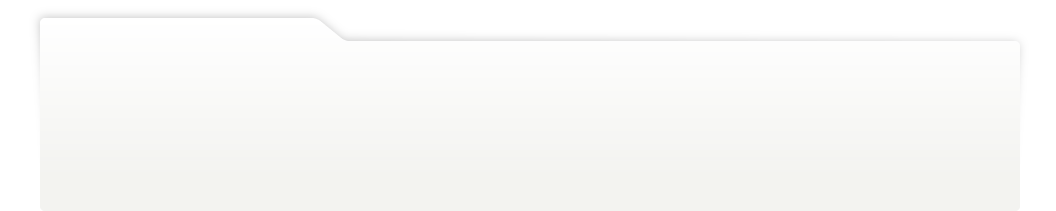
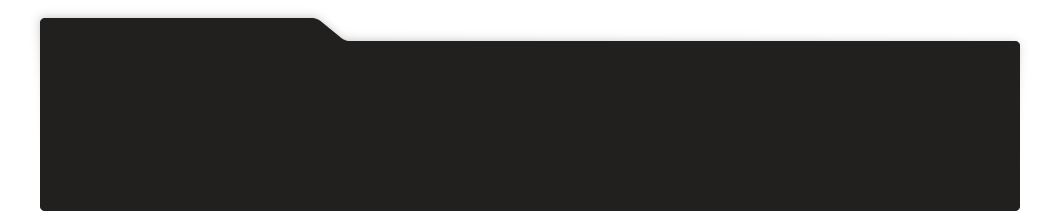
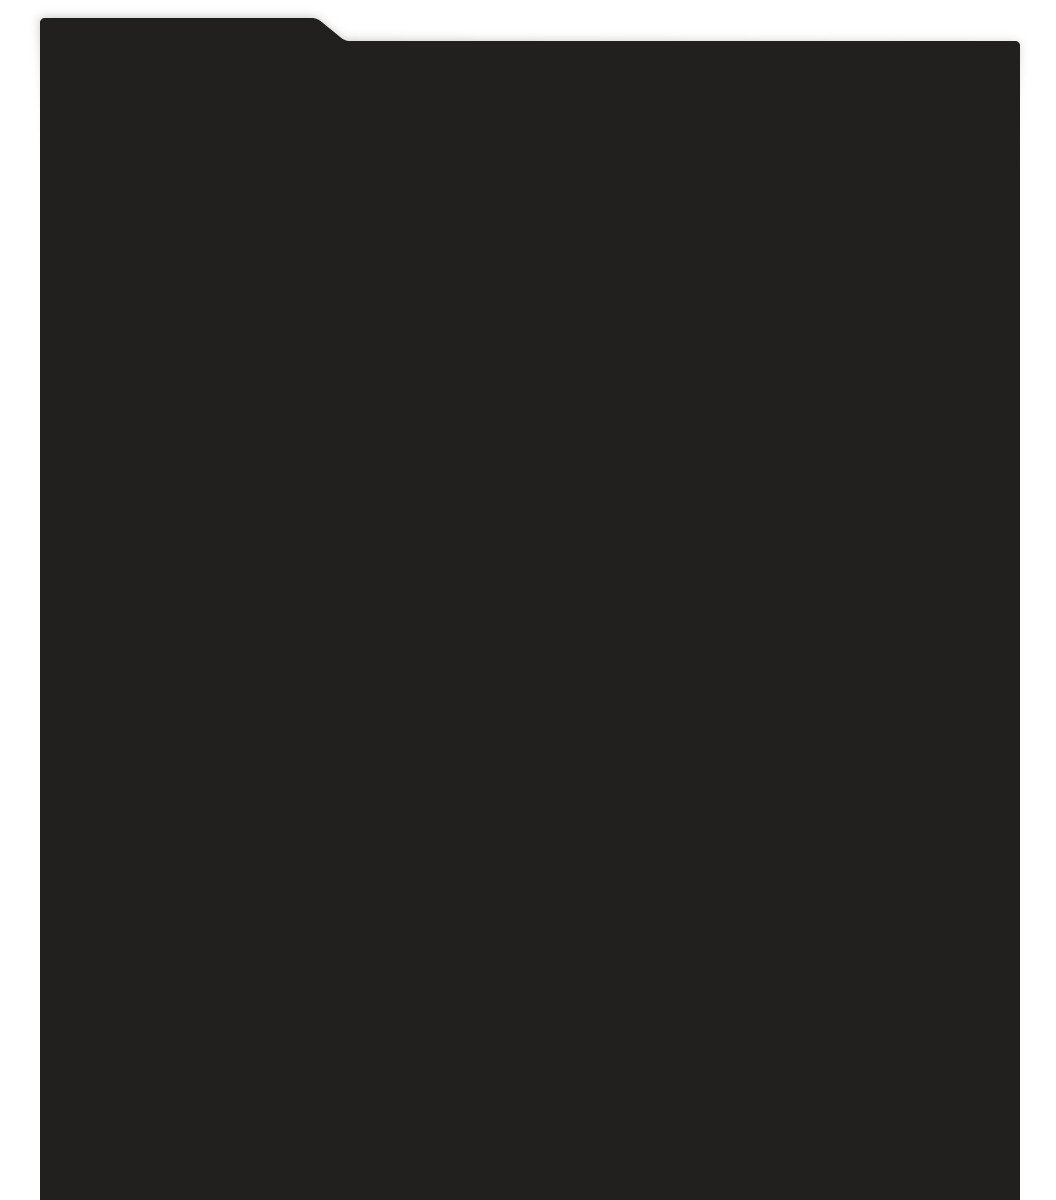
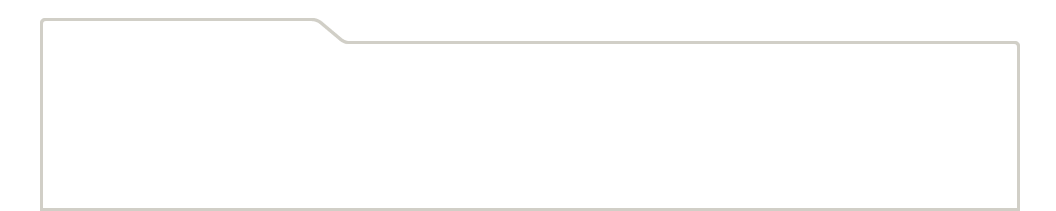
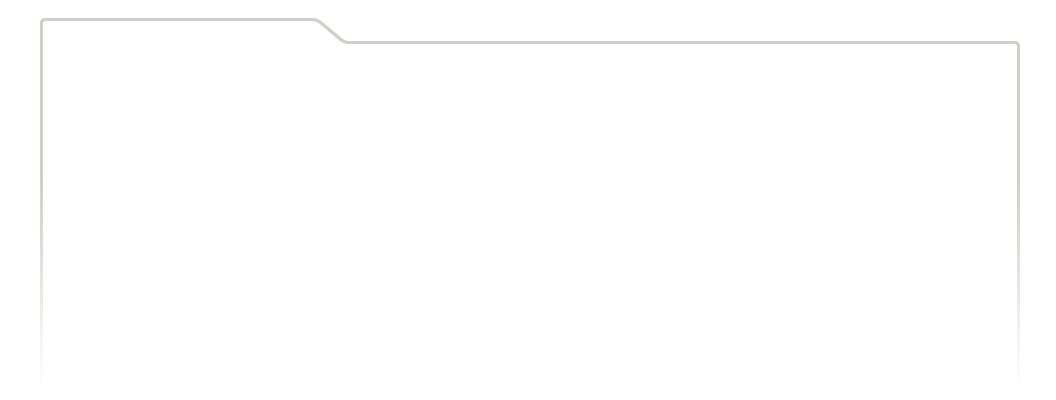
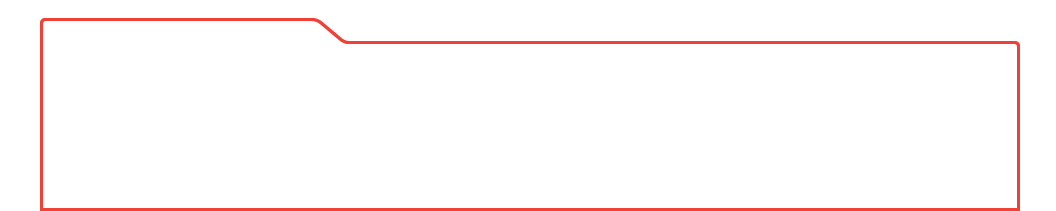
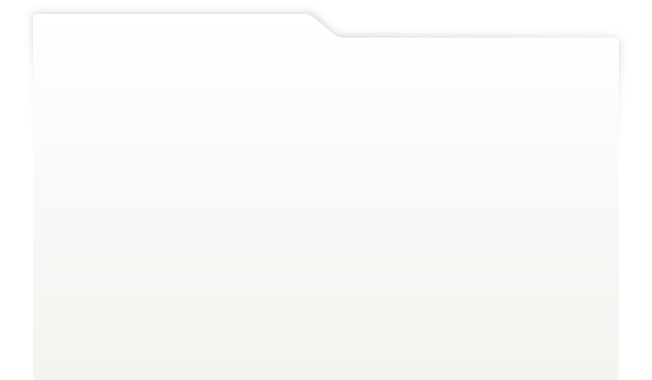
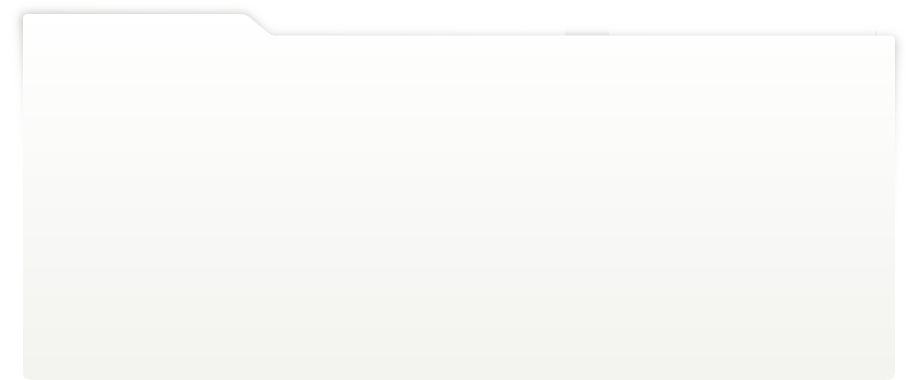
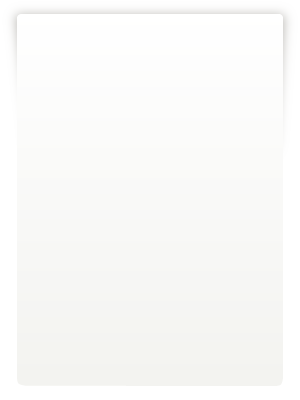
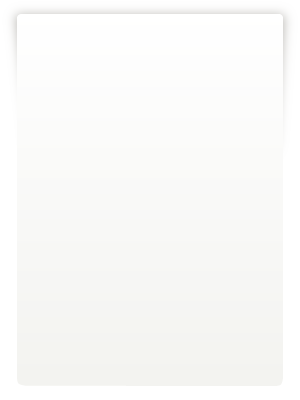
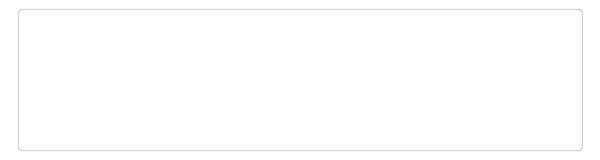
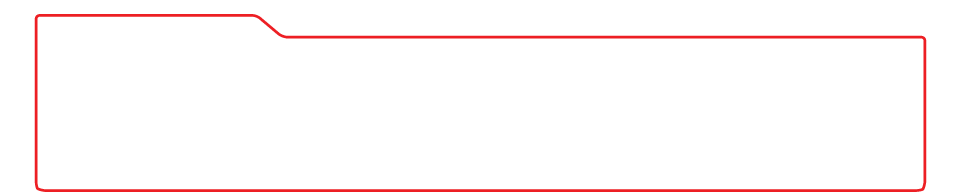
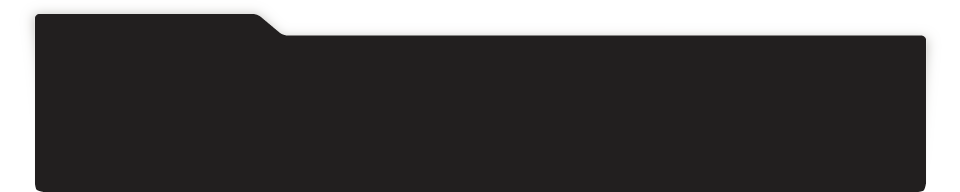
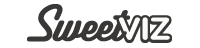
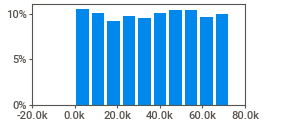
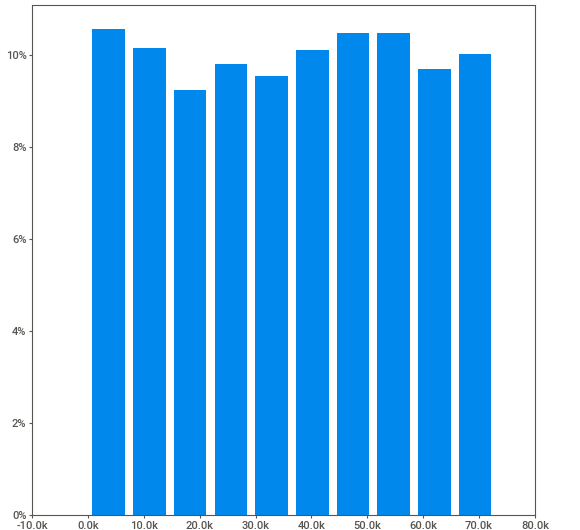
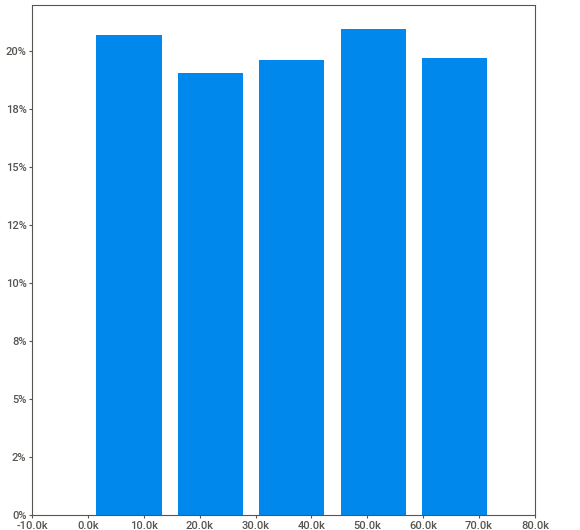
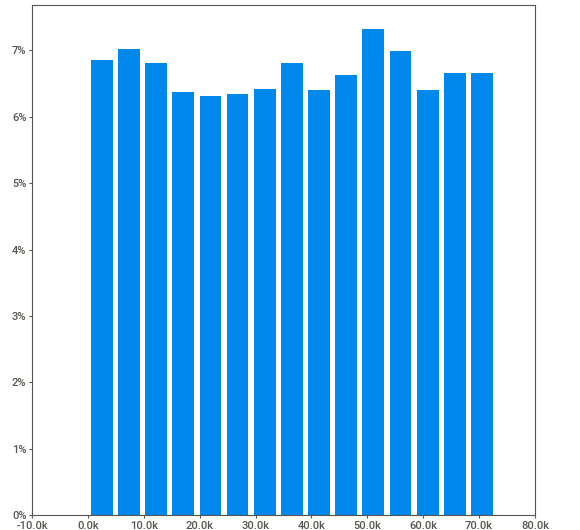
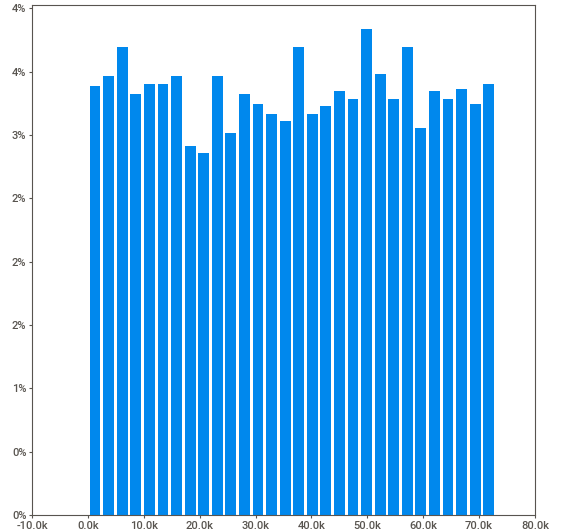
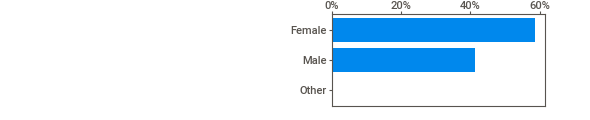
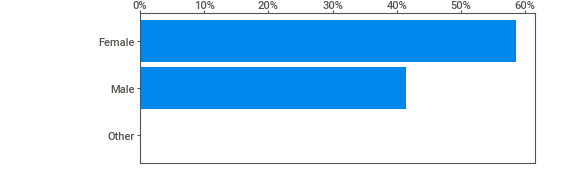
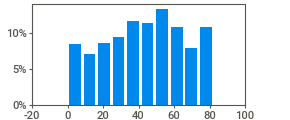
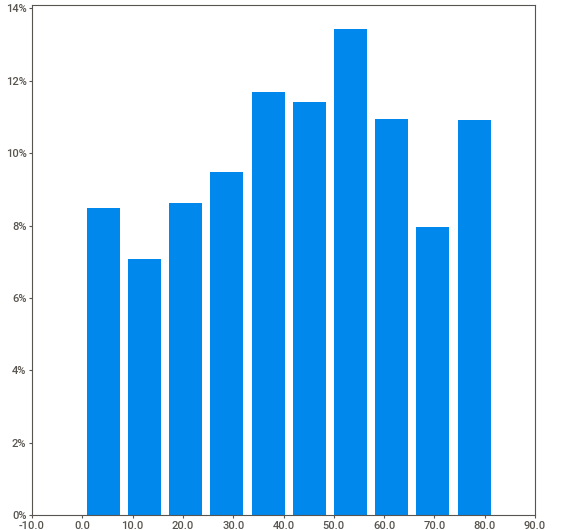
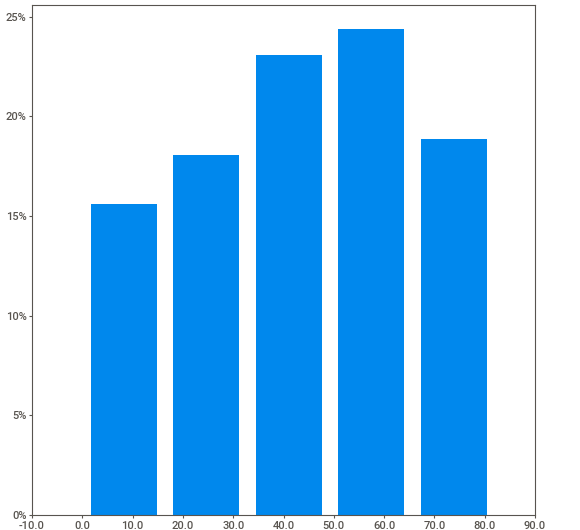
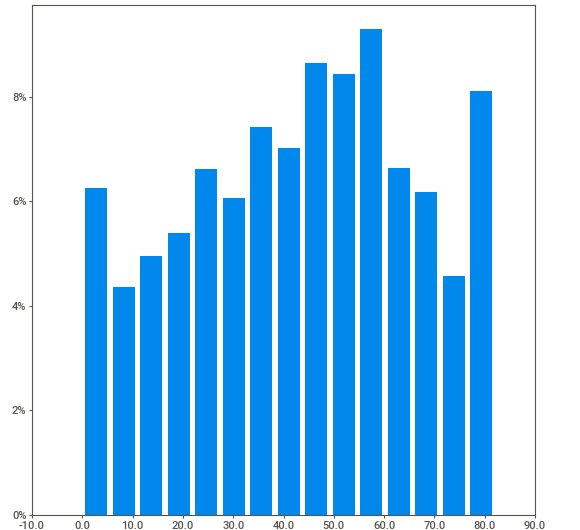
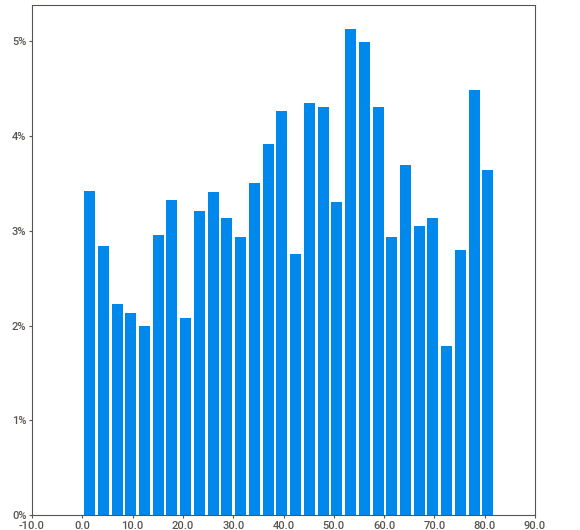
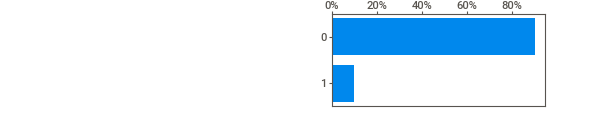
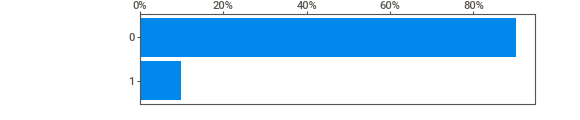
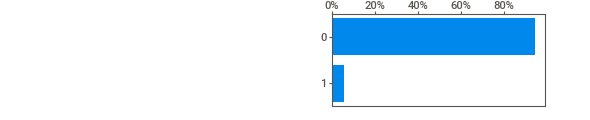
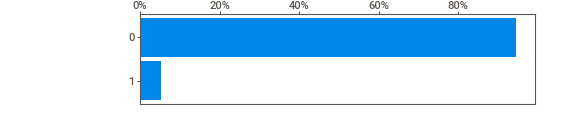
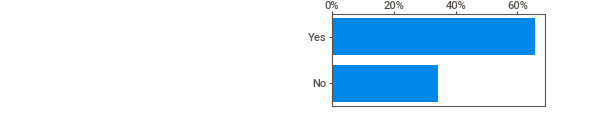
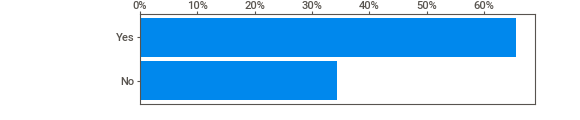
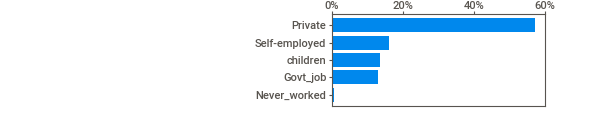
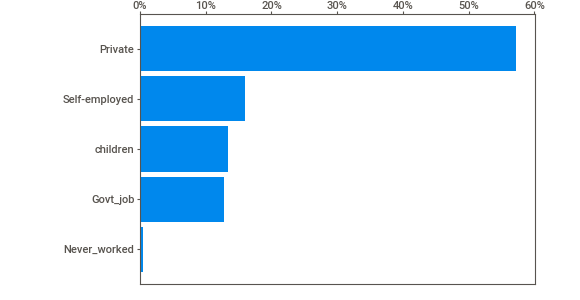
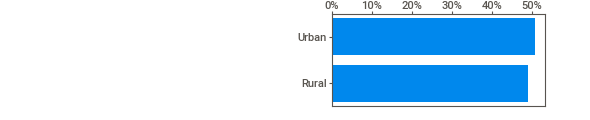
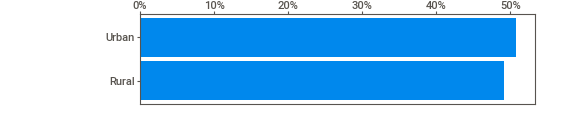
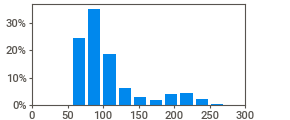
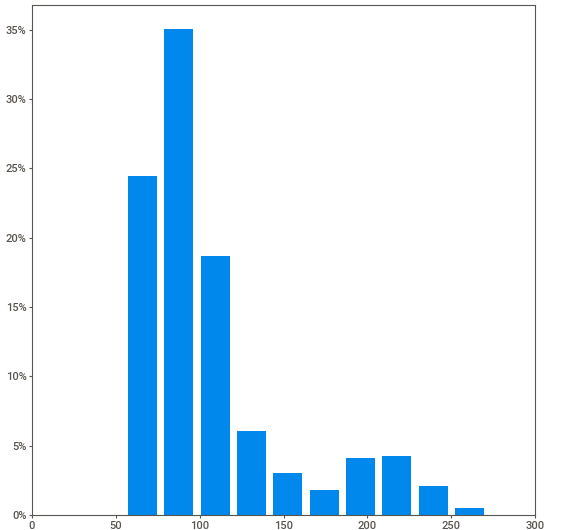
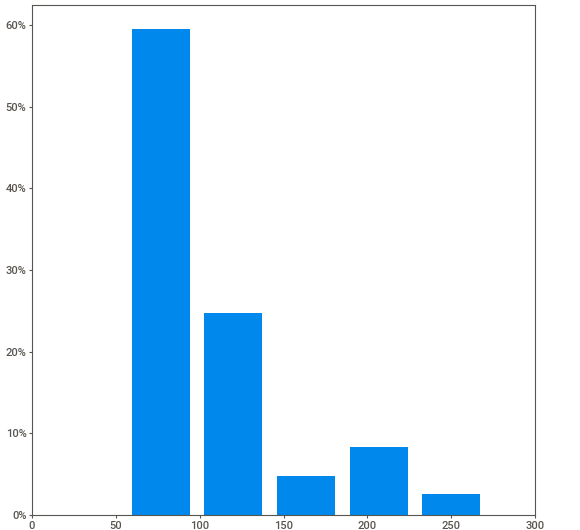
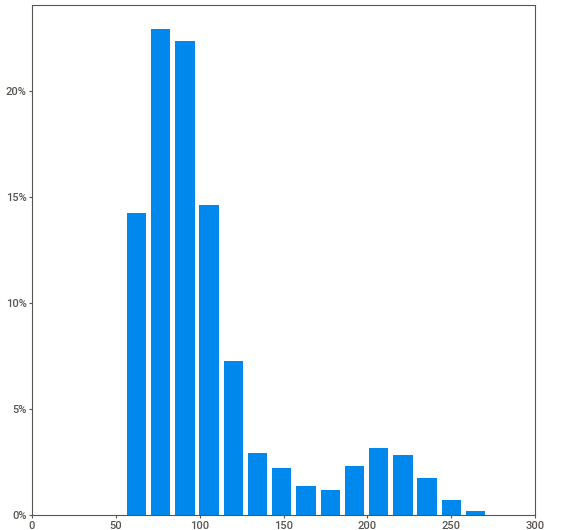
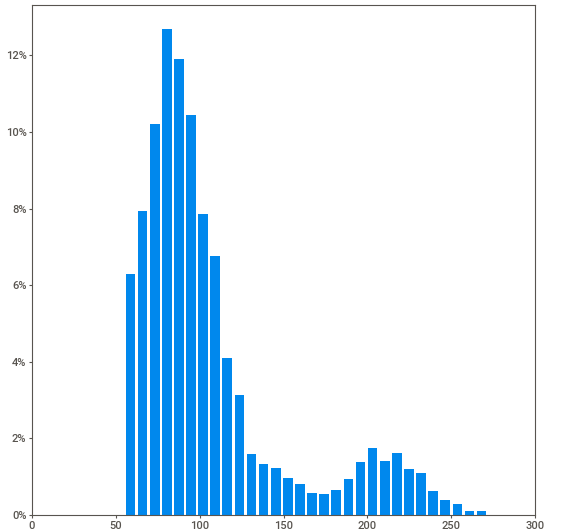
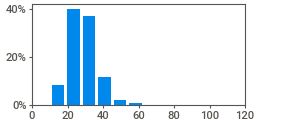
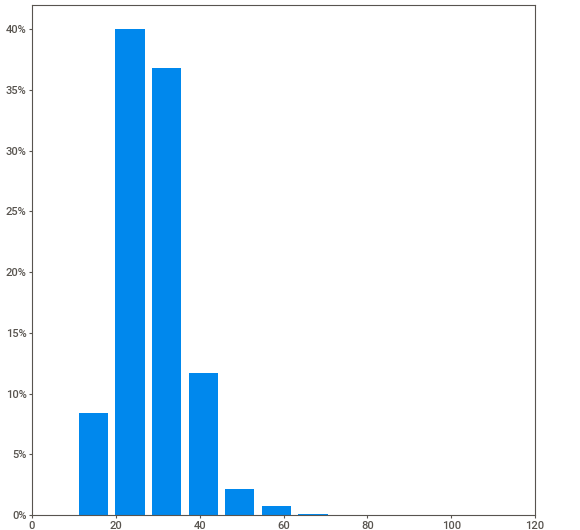
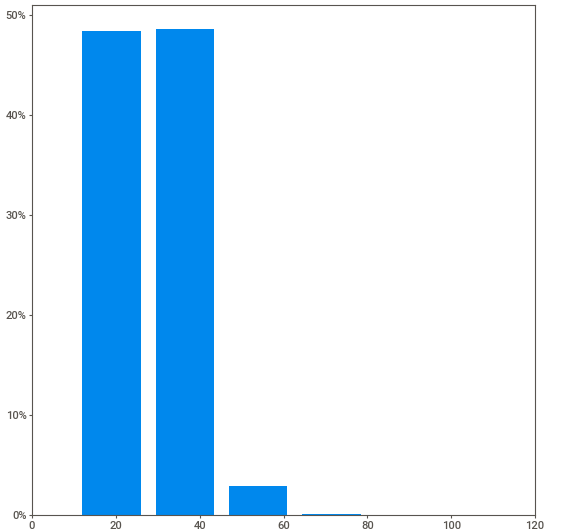
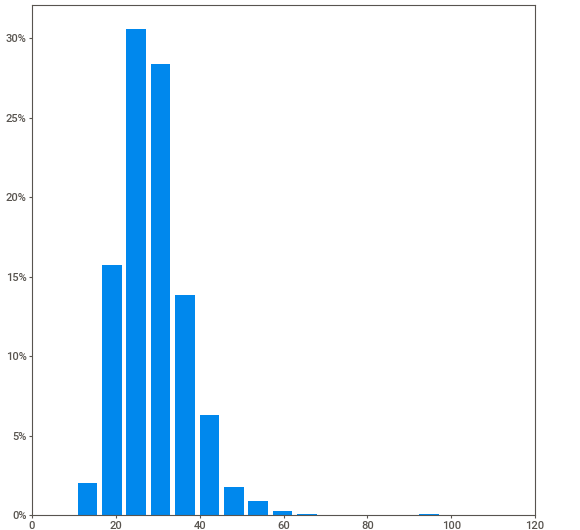
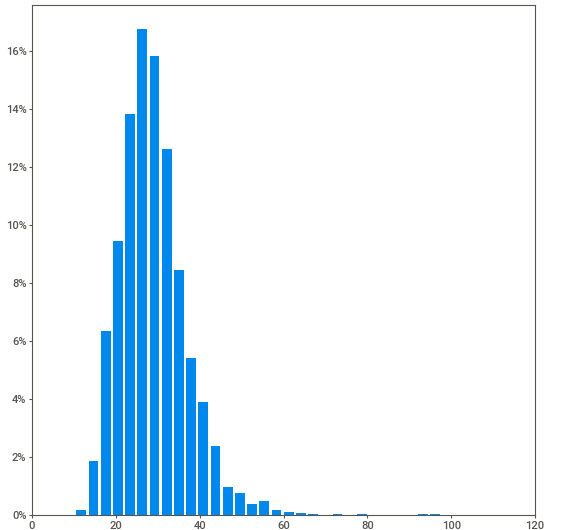
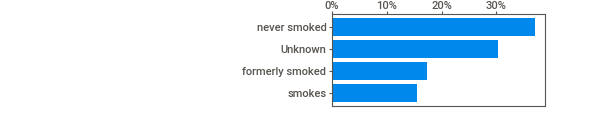
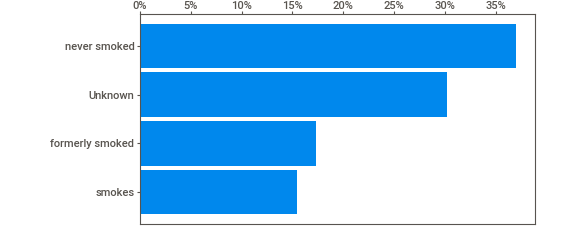
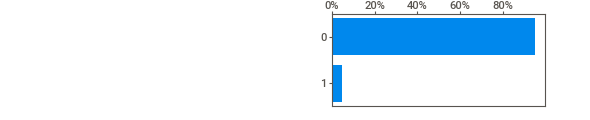
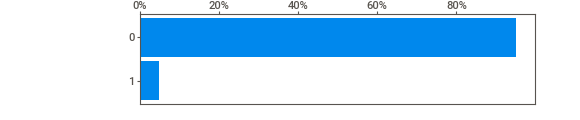
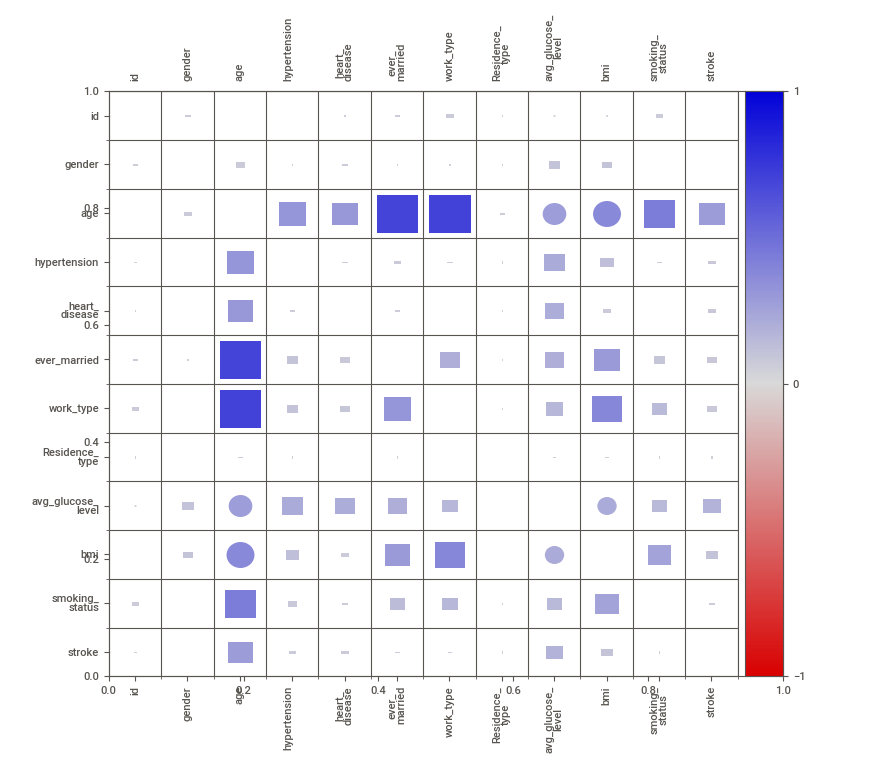
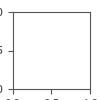

In [6]:
report_sv = sv.analyze(data)
report_sv.show_notebook()

In [7]:
report_ydp = ProfileReport(data, explorative=True)
report_ydp.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 328.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

✍️ **Interpretación:**
(Escribir aquí hallazgos relevantes y comparación entre librerías).

Tanto sweetviz como ydata profiling proporcionan un reporte completo donde podemos ver facilmente la correlacion entre los datos, su distribución, entre otras caracteristicas.

Si bien ydata profiling tarda más en generar el reporte, debido a la poca cantidad de datos y carácteristicas, el tiempo que terdaron ambas librerías es muy similar.

En cuanto a las funcionalidades considero que, para correlaciones, sweetviz es mucho más intuitiva ya que, por cada variable, se nos muestran unas tablas con aquellas variables más relacionadas a la variable en cuestión, lo que hace la visualización de estas relaciones mucho más sencilla, directa y entendible.

A diferencia de ydata profiling, donde esta información se muestra unicamente al final del documento en un heatmap, lo cual lo hace ligeramente menos directo y legible, especialmente para aquellos datasets con una gran cantidad de carácteristicas.

Con respecto al resto de funcionalidades, considero ydata profiling mucho más completo. Esto ya que, adicional a la información que también es mostrada por sweetviz, se nos muestran las filas duplicadas, valores faltantes, interaciones entre variables entre muchos otros datos derivados de cada variable.
Así como una lista de alertas donde se nos muestran advertencias de alta correlación, datos inbalanceados y valores faltantes, característica la cual sweetviz no tiene.


##  Pregunta 2 – Análisis por cortes
- Definir **dos variables de corte distintas** (ejemplo: género, edad > 50, hipertensión, etc.).  
- Interpretar resultados y justificar la elección de las variables.  


                                             |          | [  0%]   00:00 -> (? left)


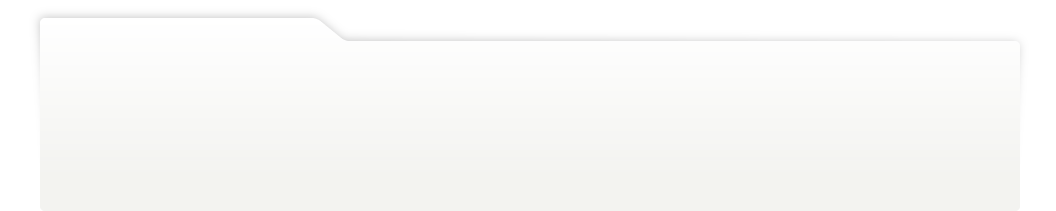
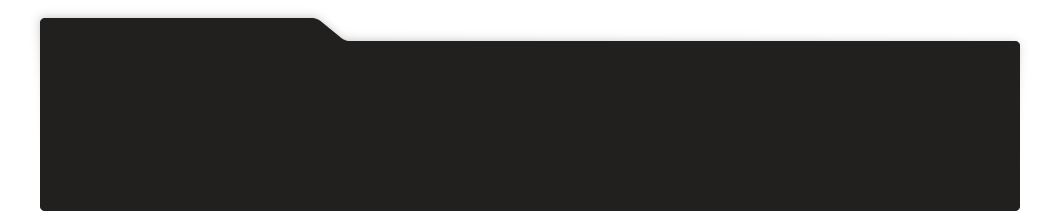
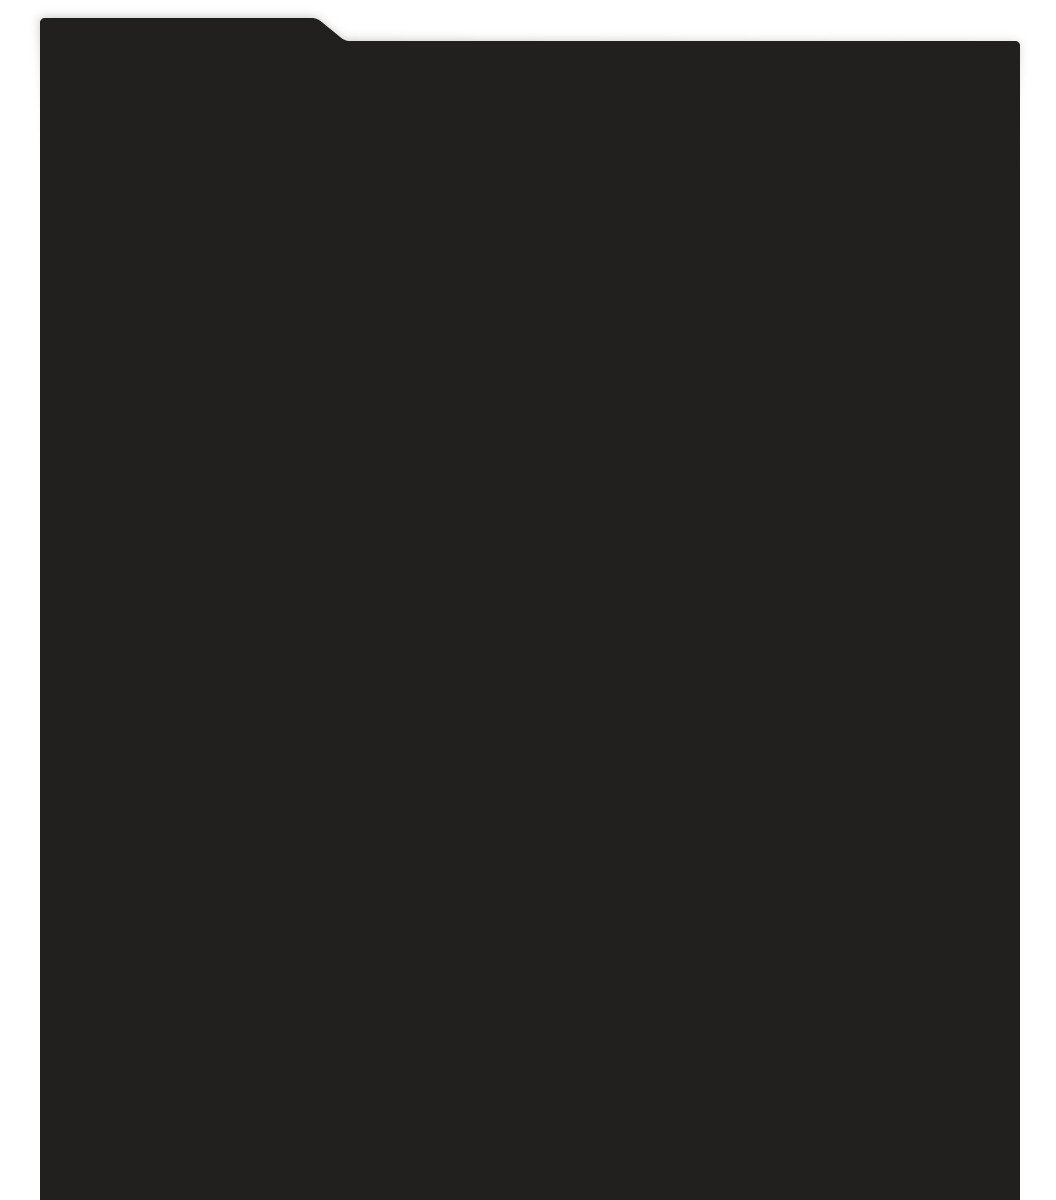
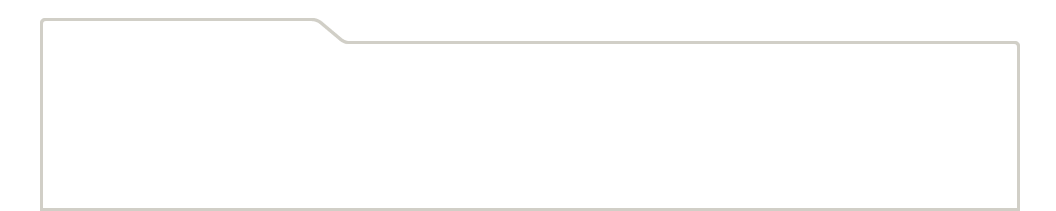
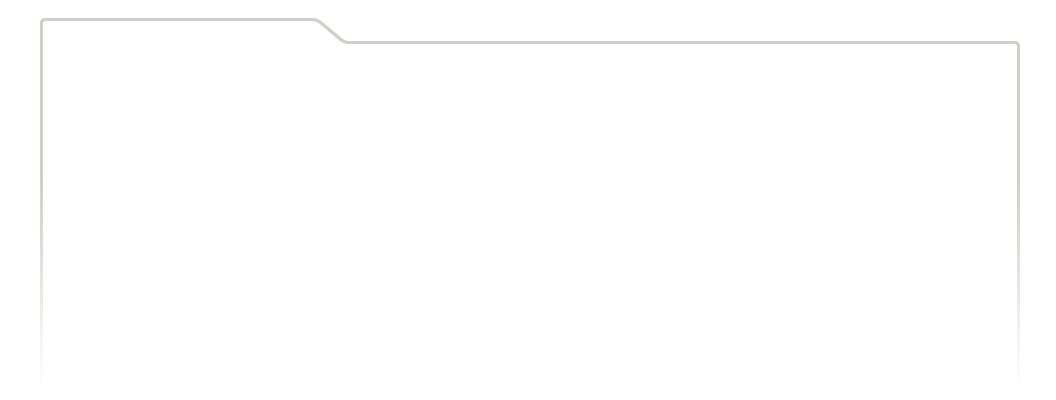
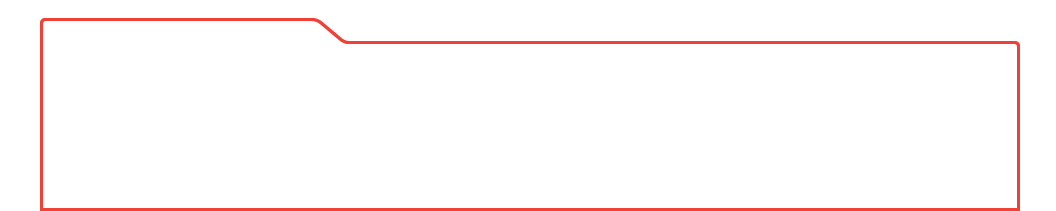
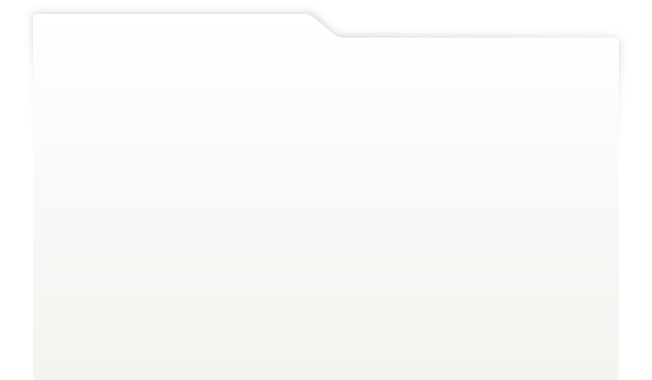
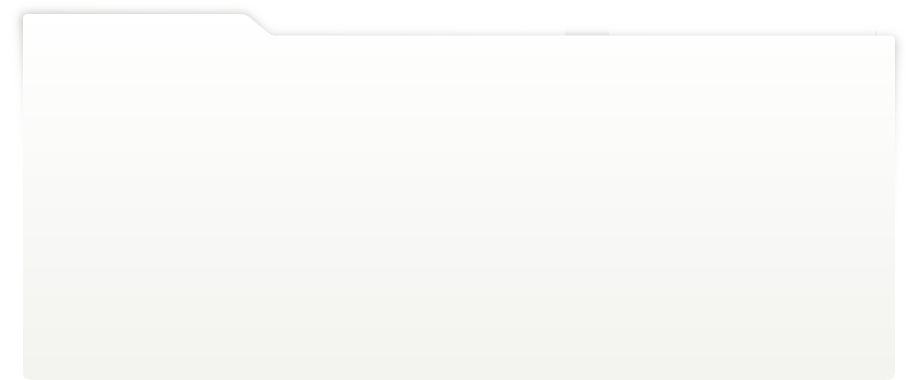
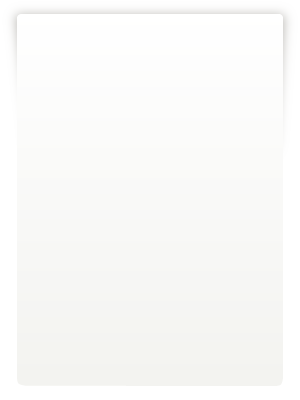
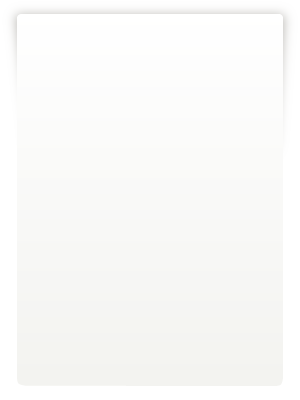
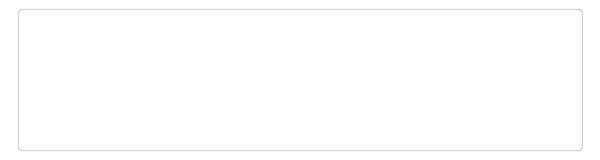
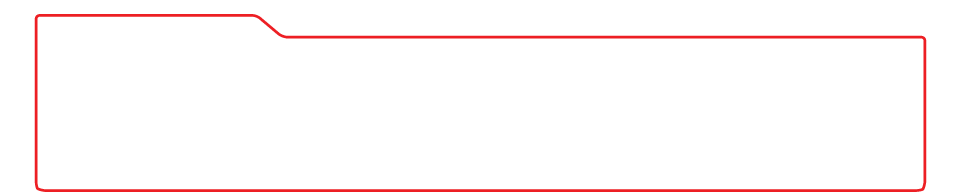
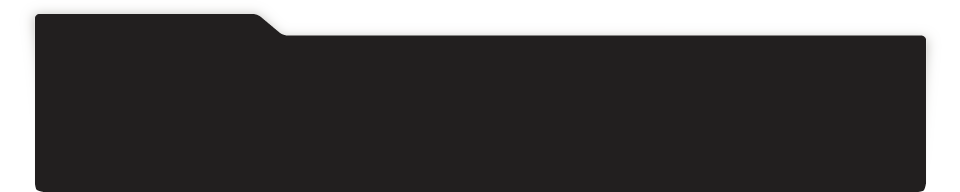
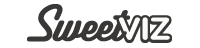
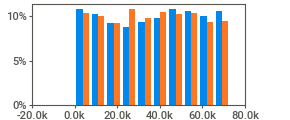
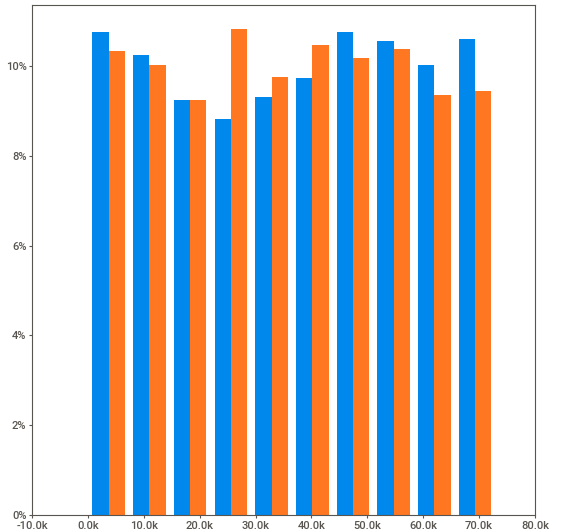
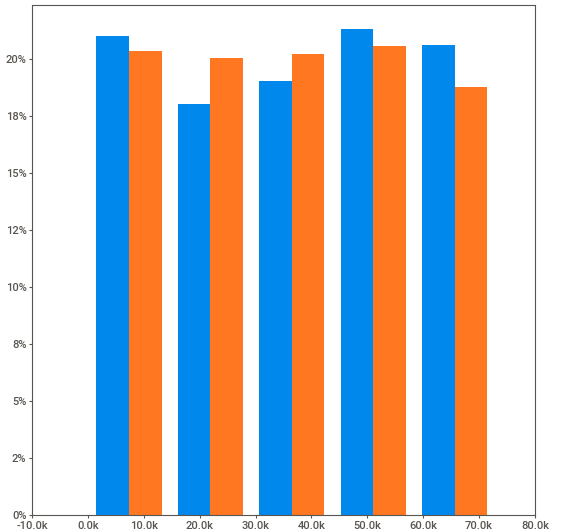
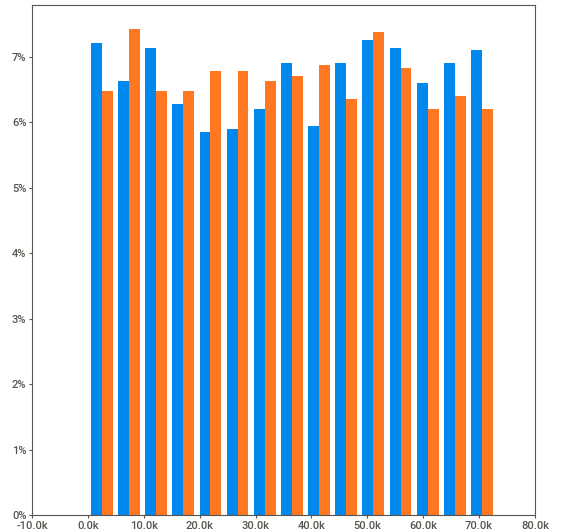
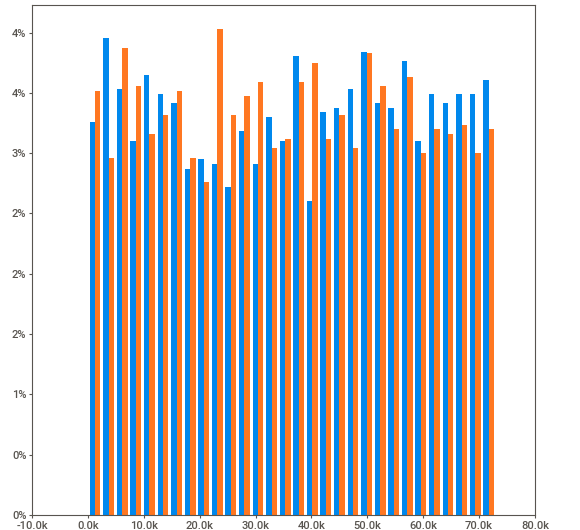
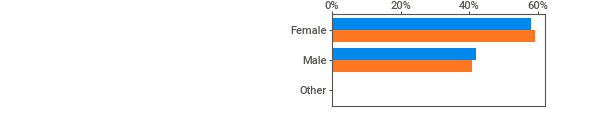
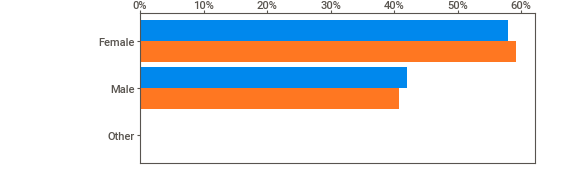
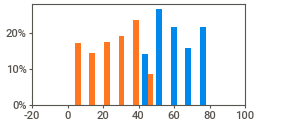
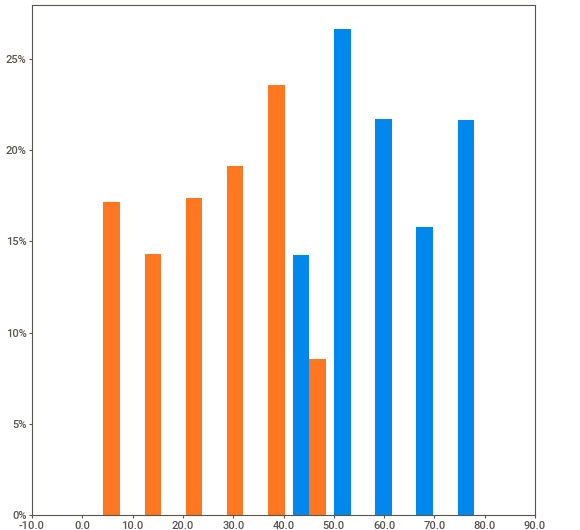
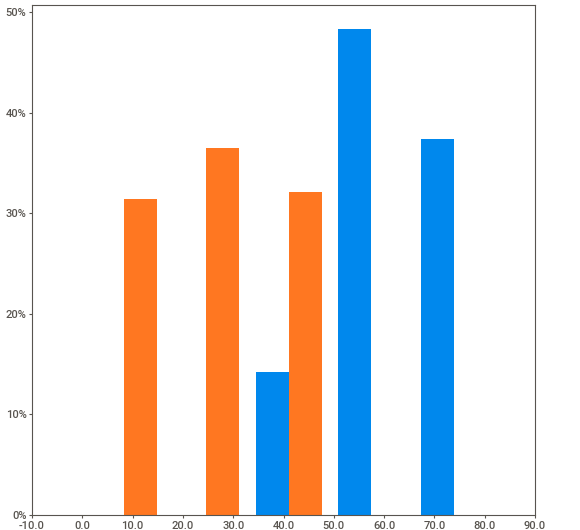
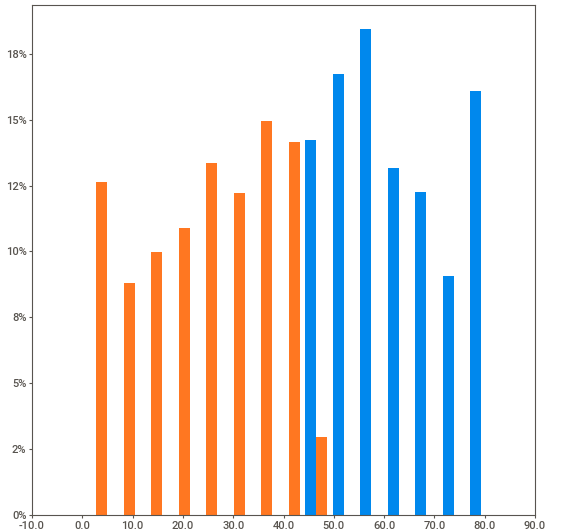
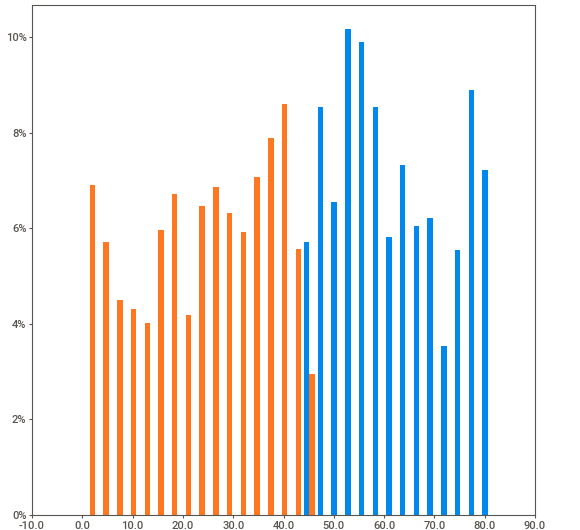
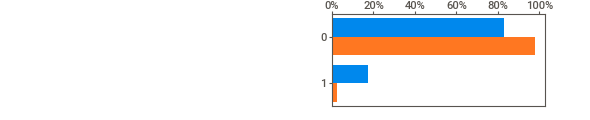
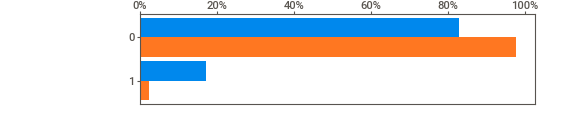
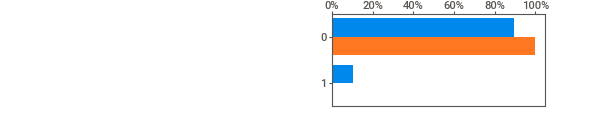
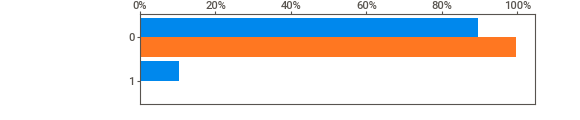
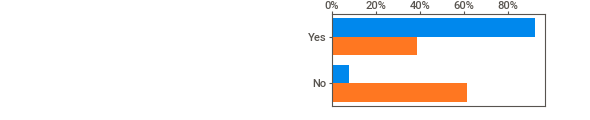
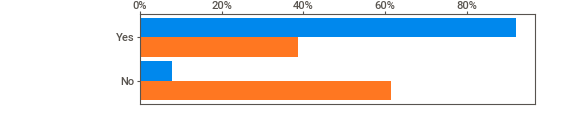
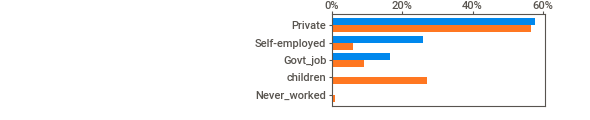
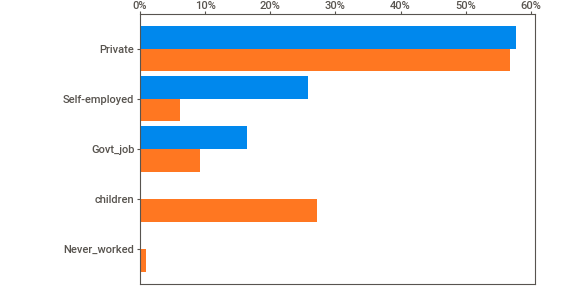
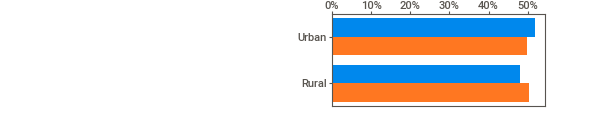
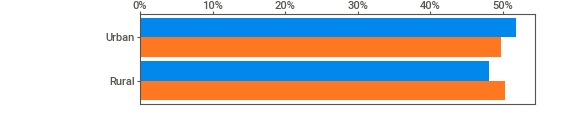
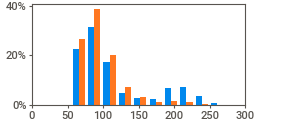
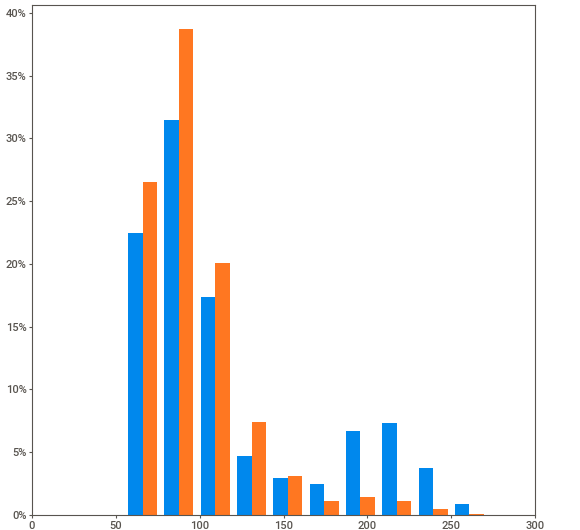
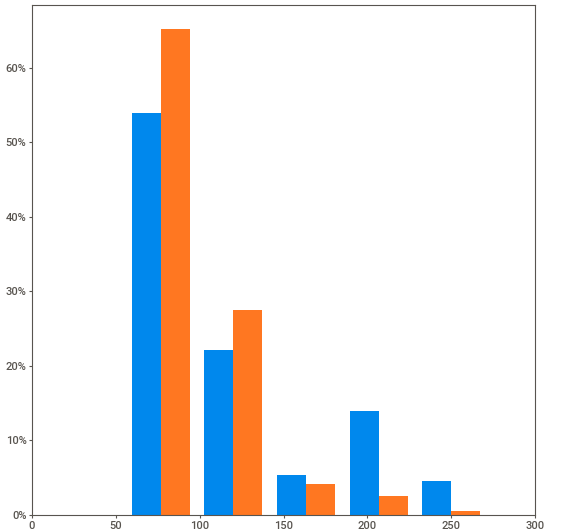
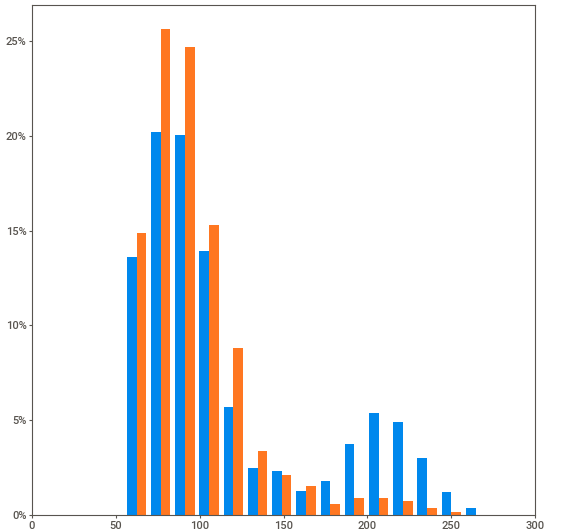
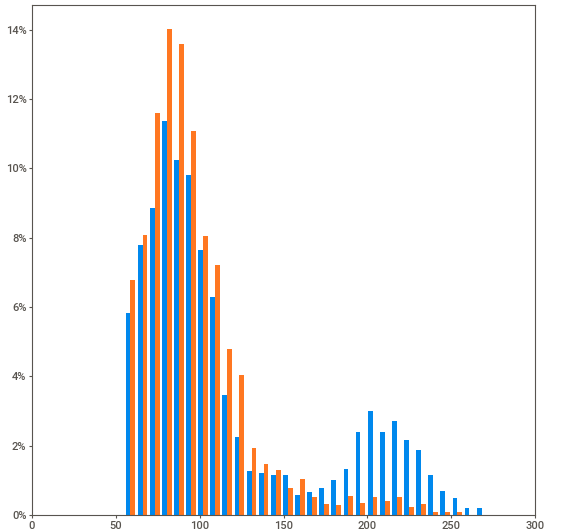
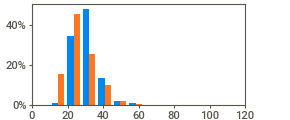
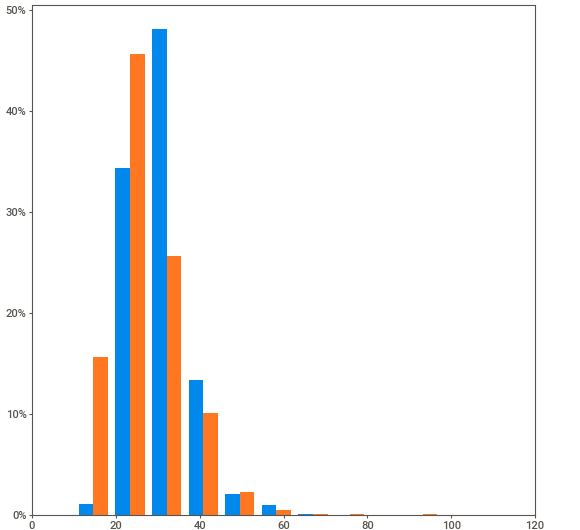
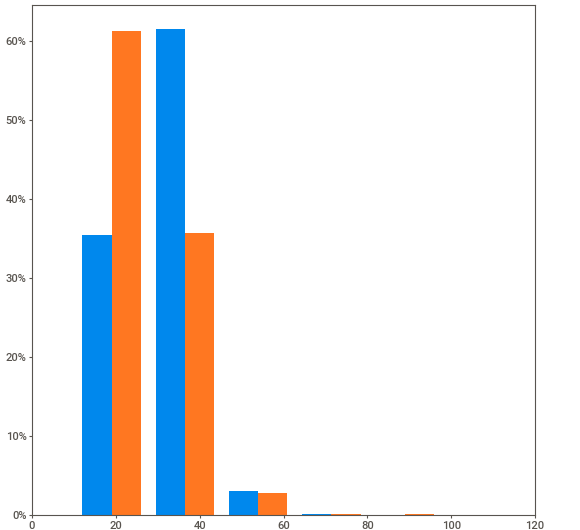
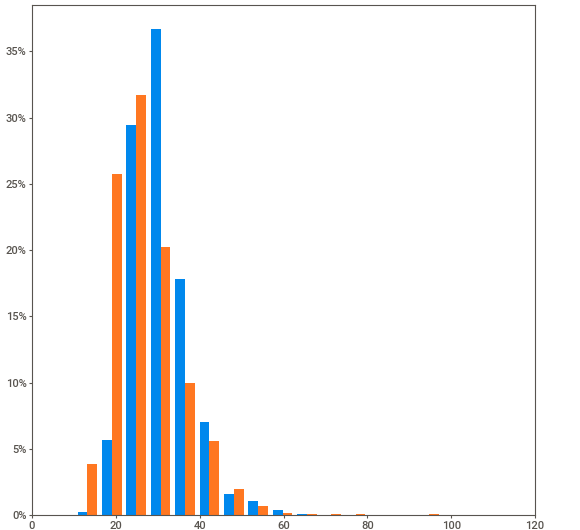
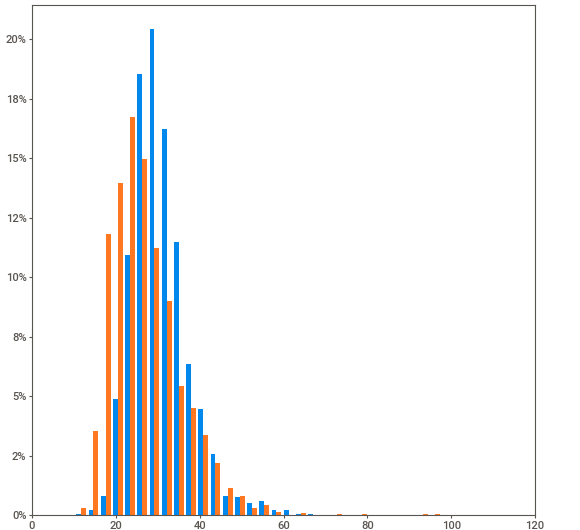
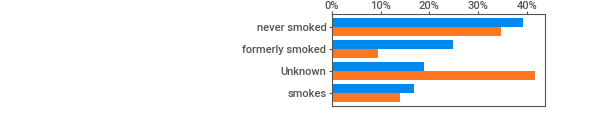
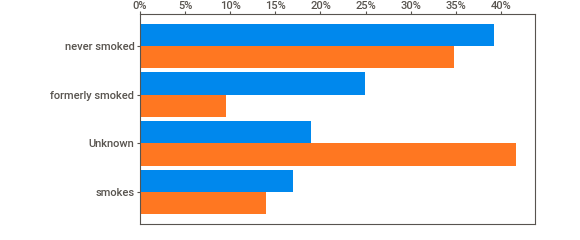
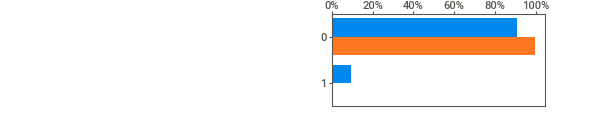
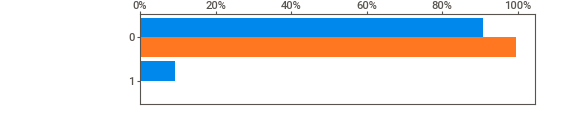
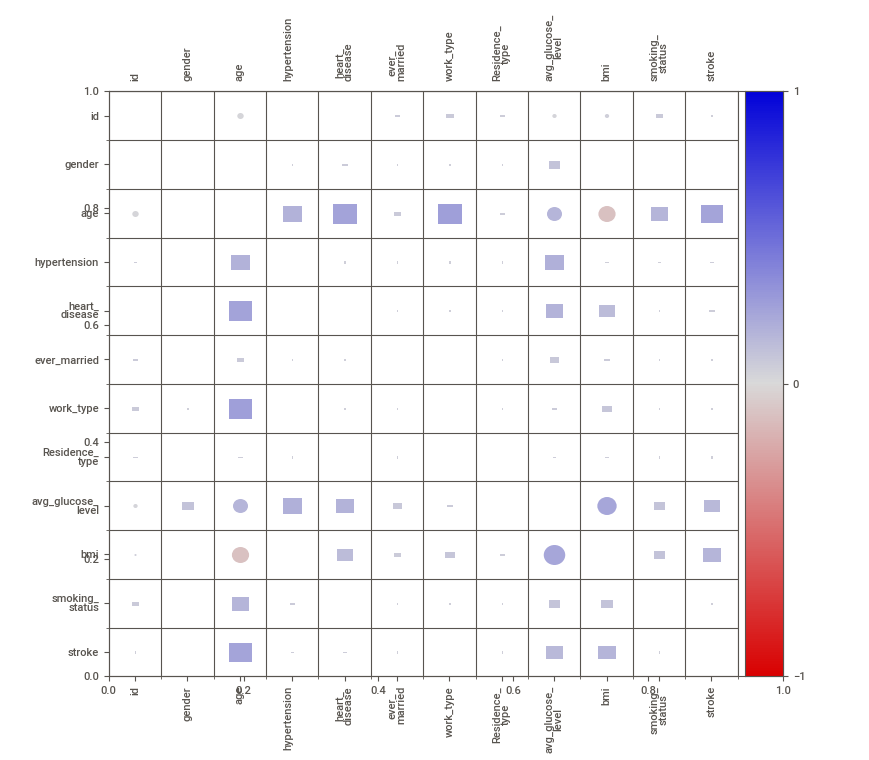
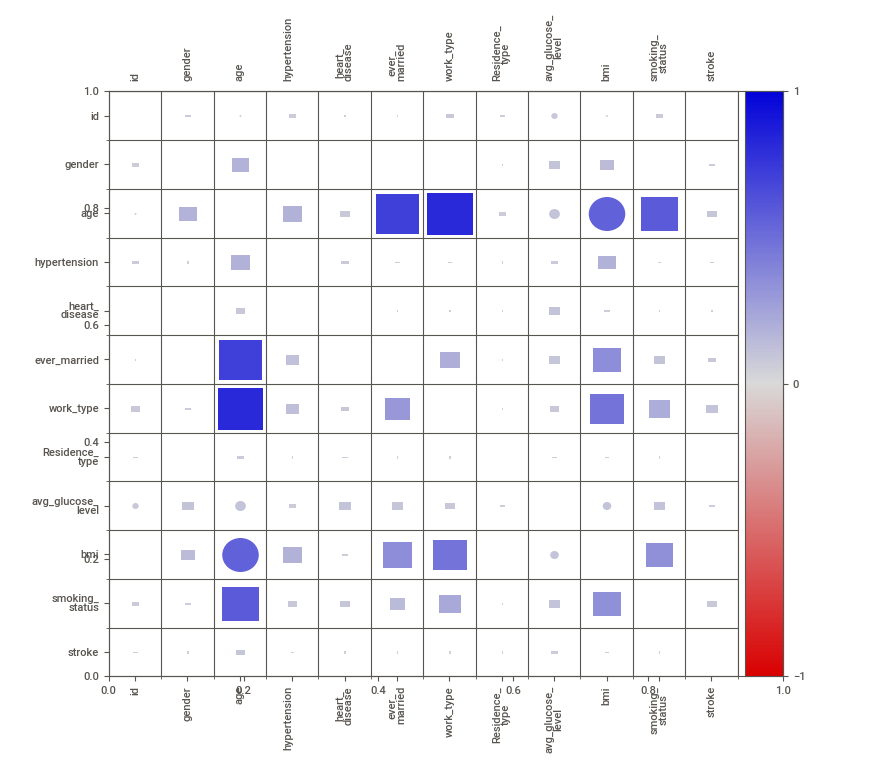

In [8]:
report_sv_age = sv.compare_intra(data,data["age"] >= 45,["Mayor de 45","Menor de 45"])
report_sv_age.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)


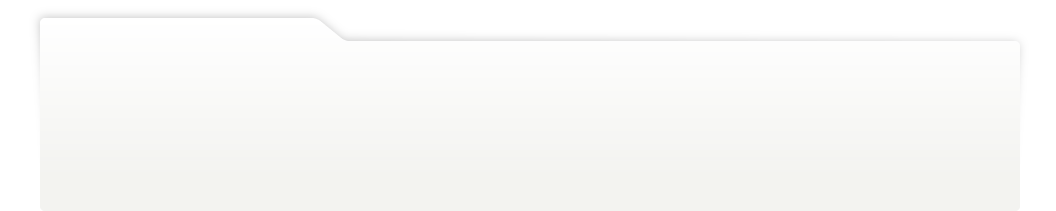
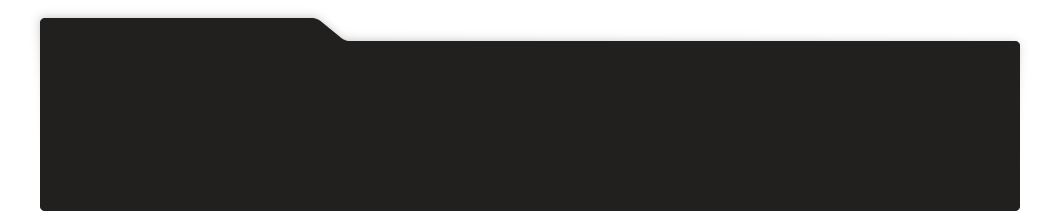
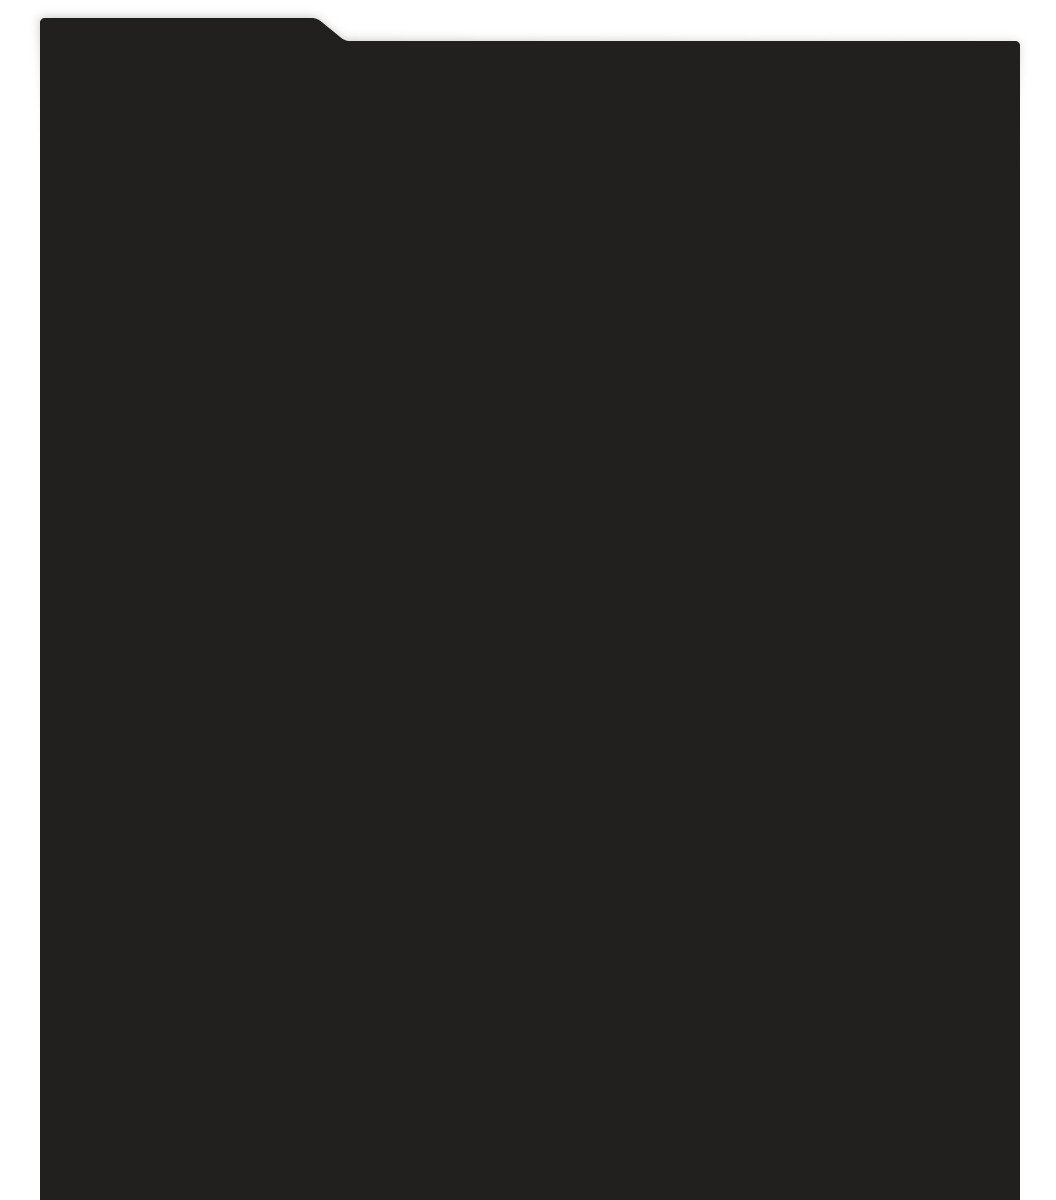
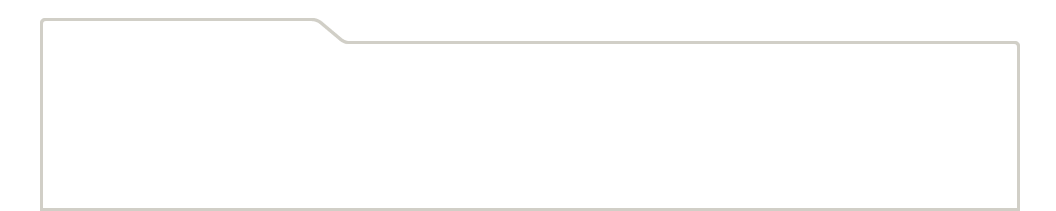
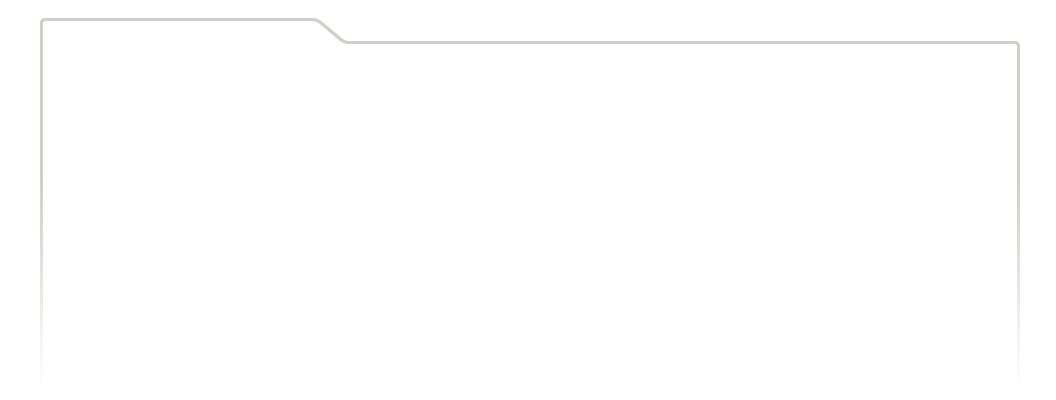
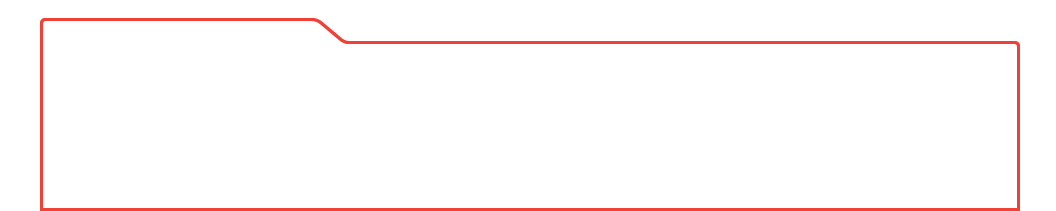
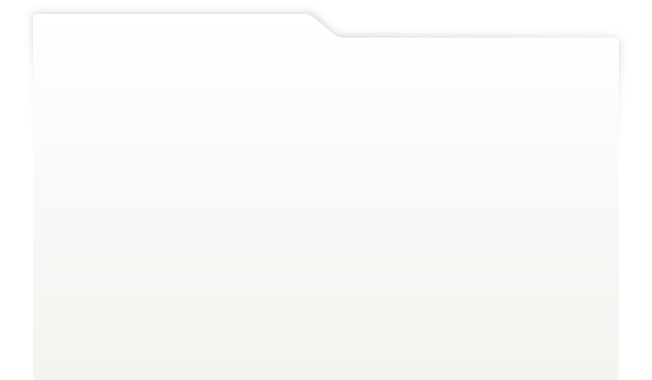
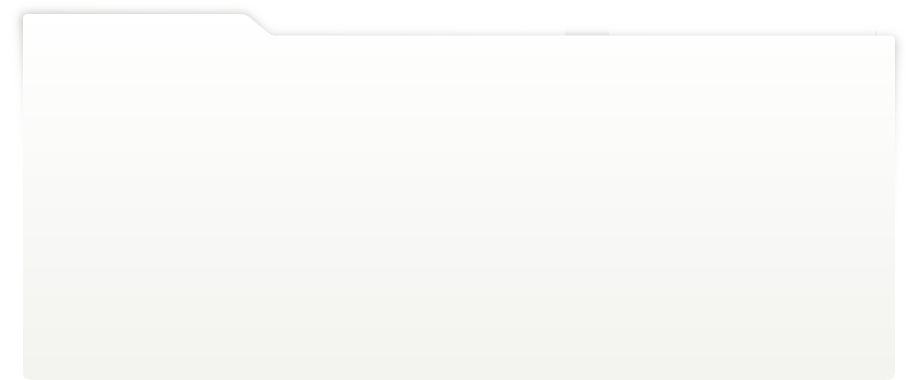
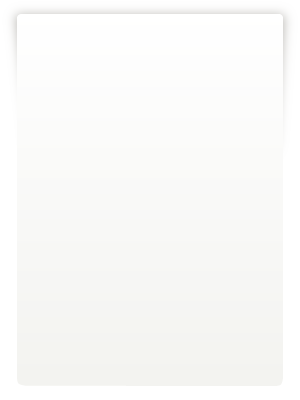
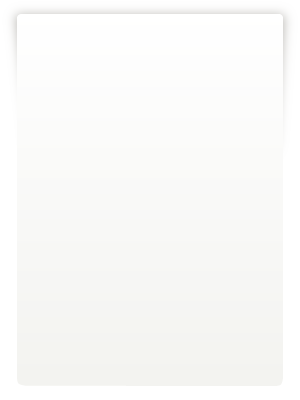
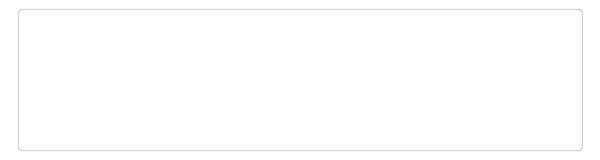
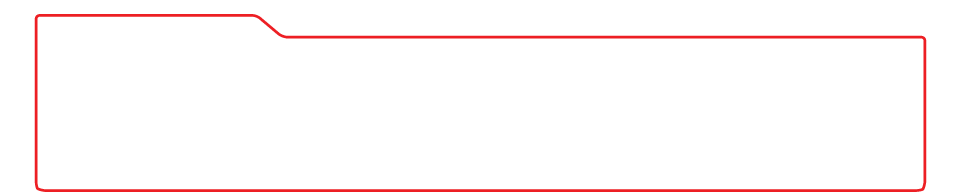
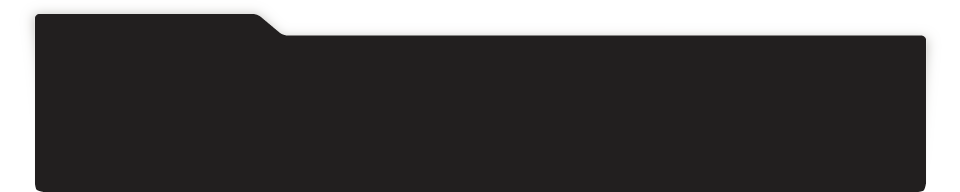
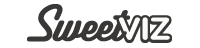
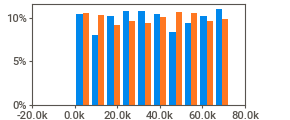
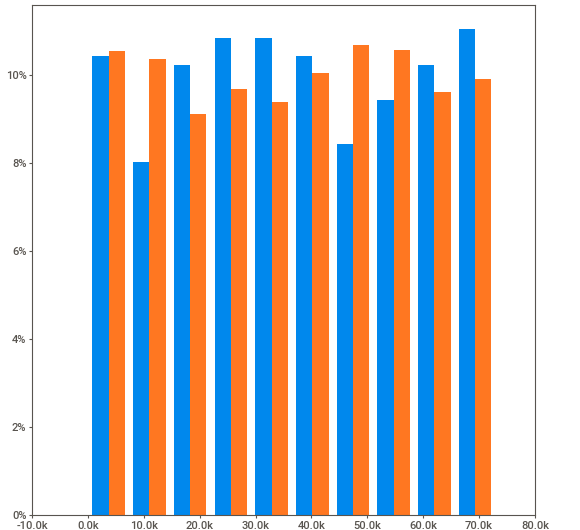
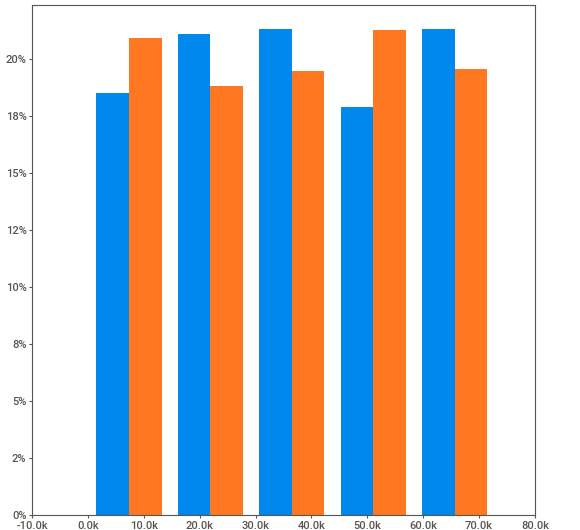
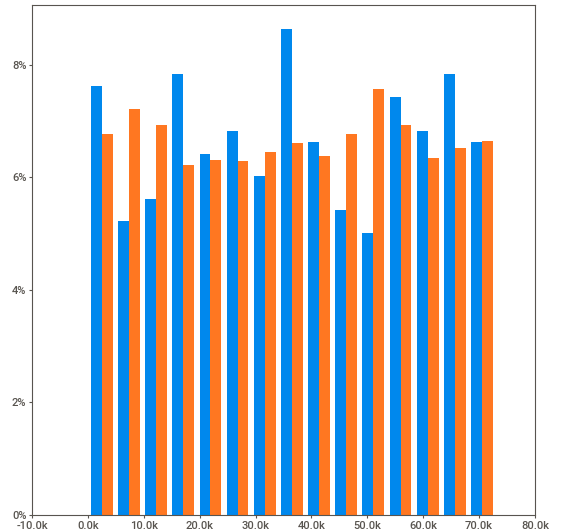
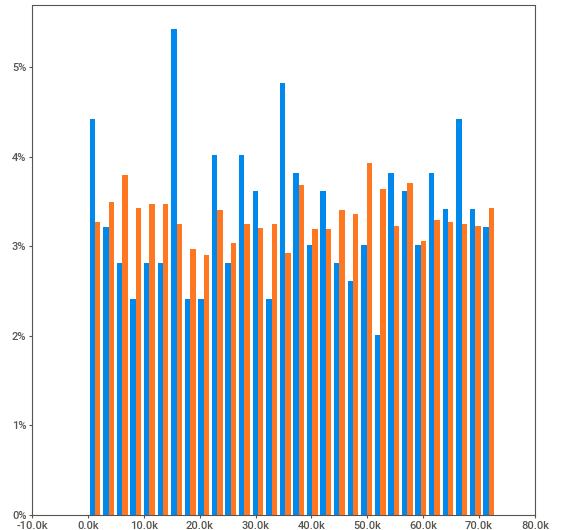
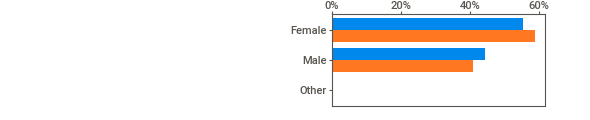
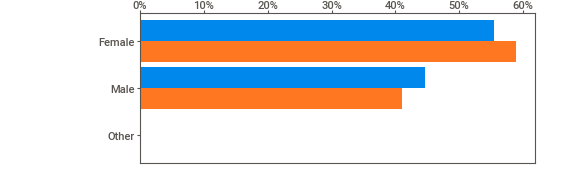
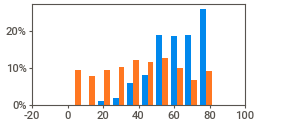
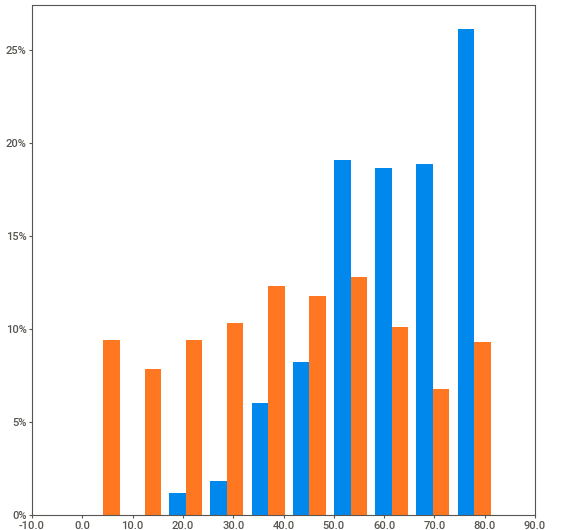
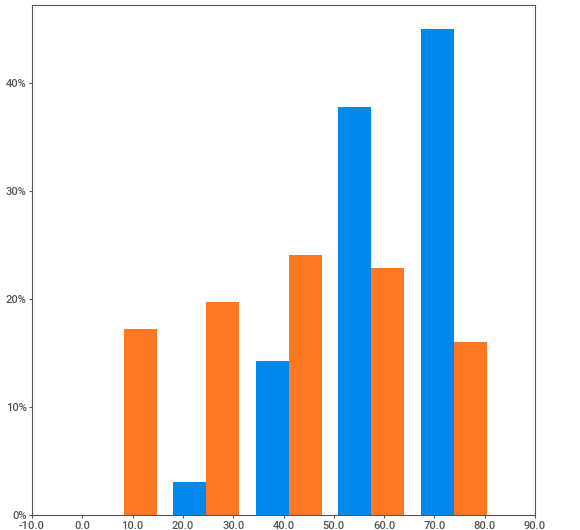
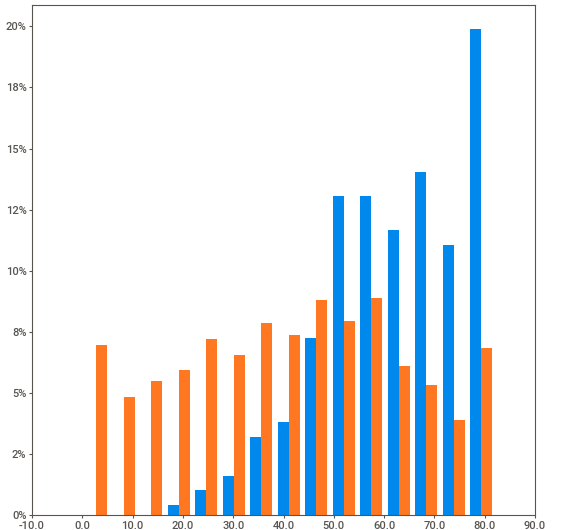
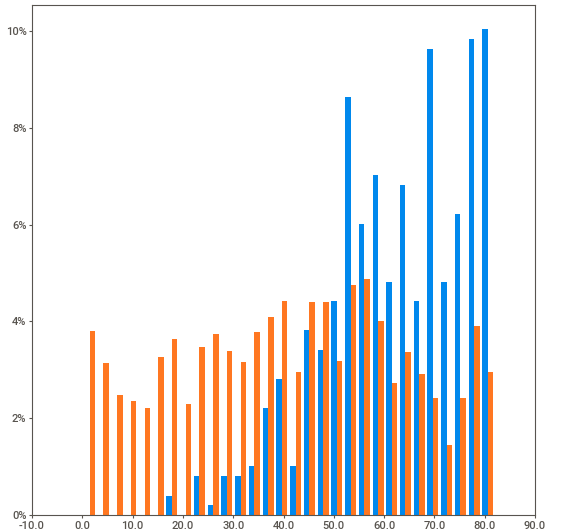
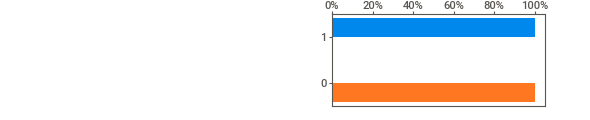
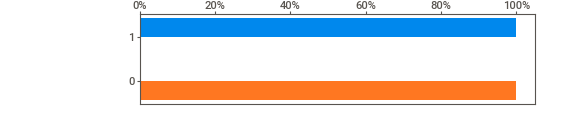
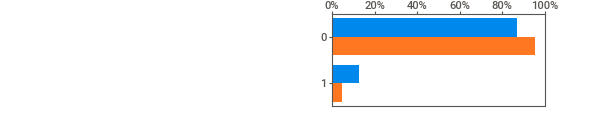
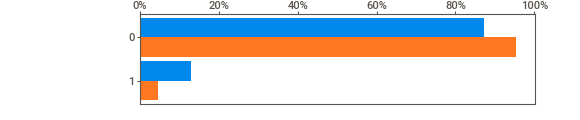
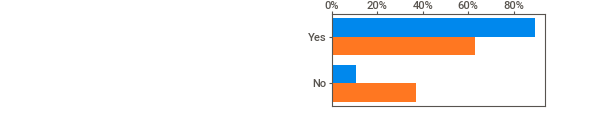
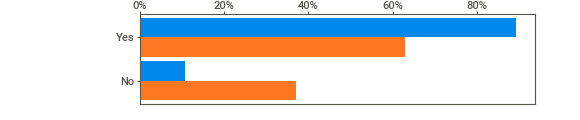
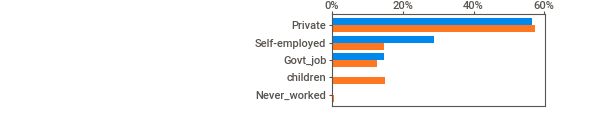
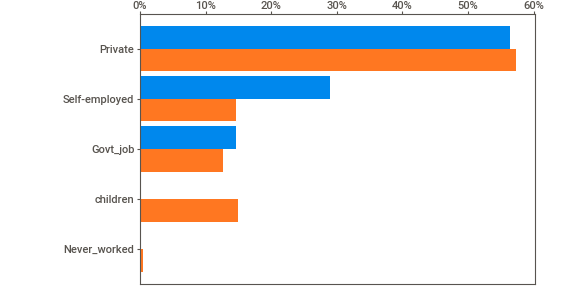
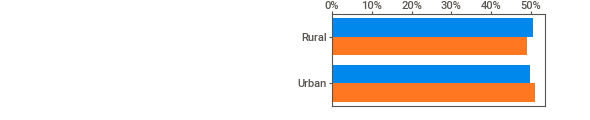
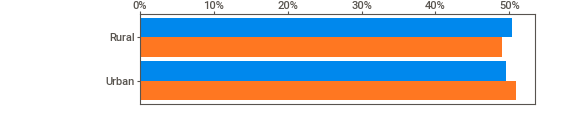
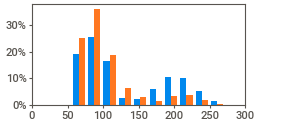
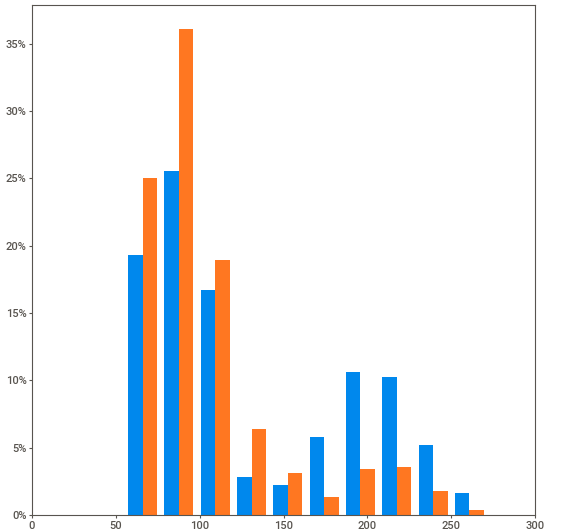
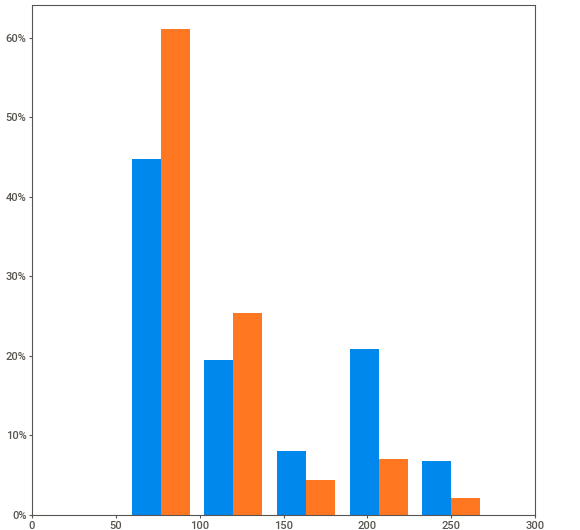
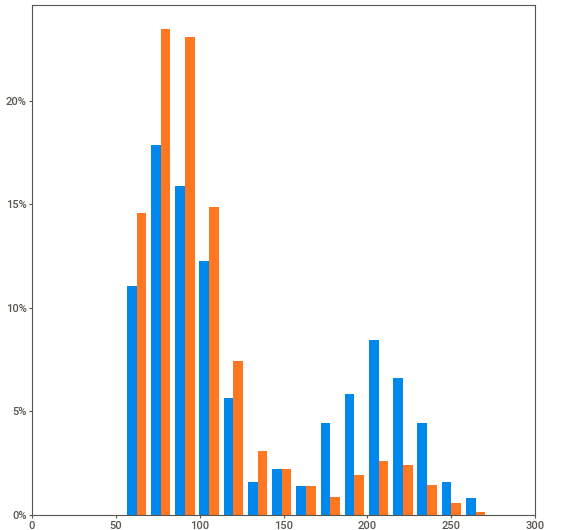
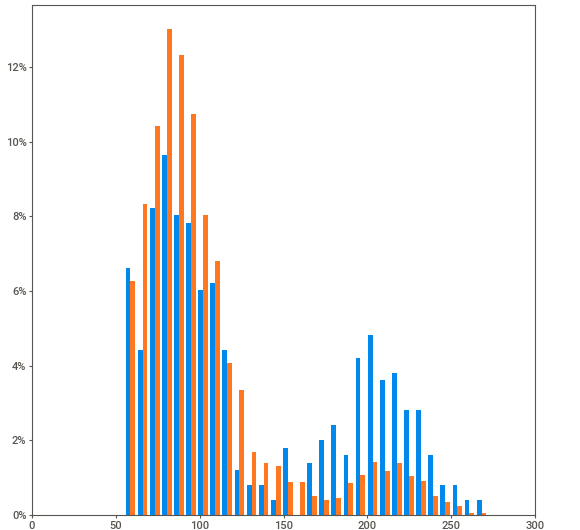
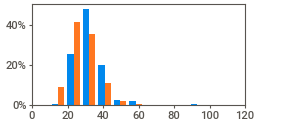
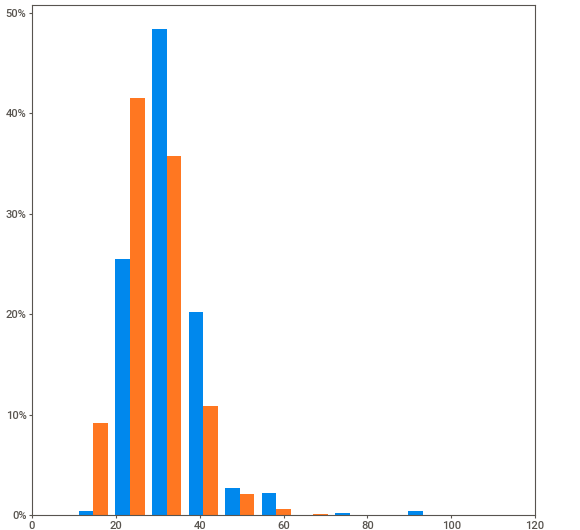
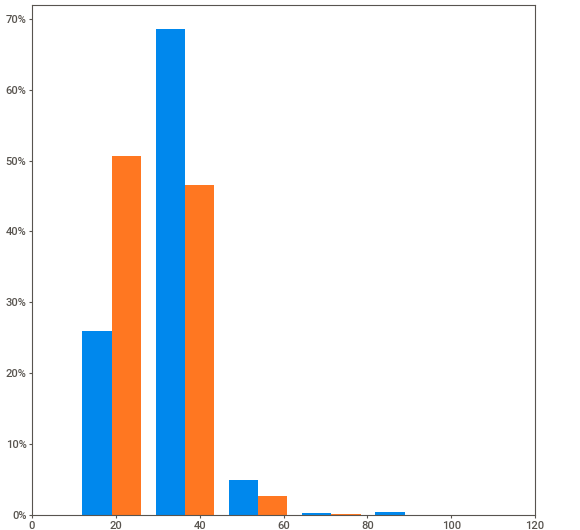
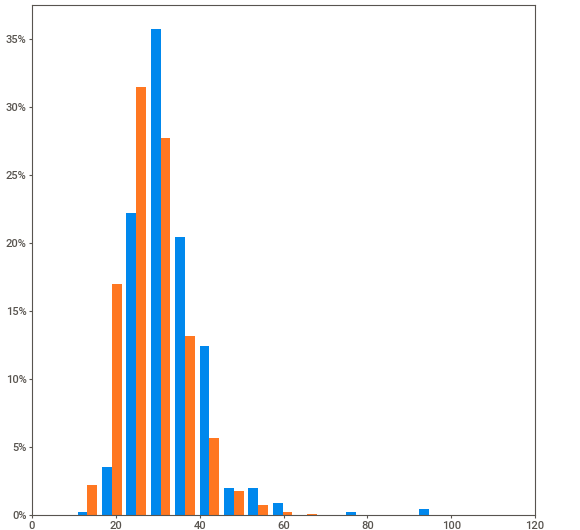
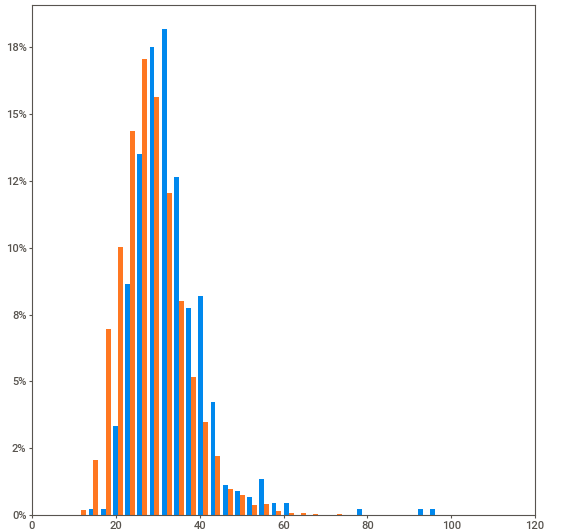
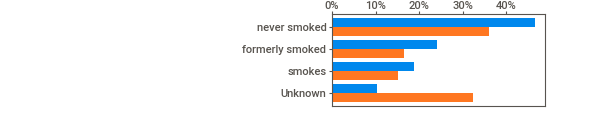
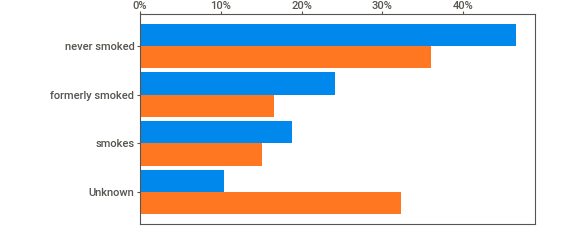
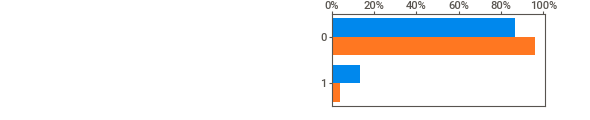
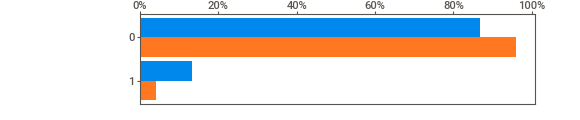
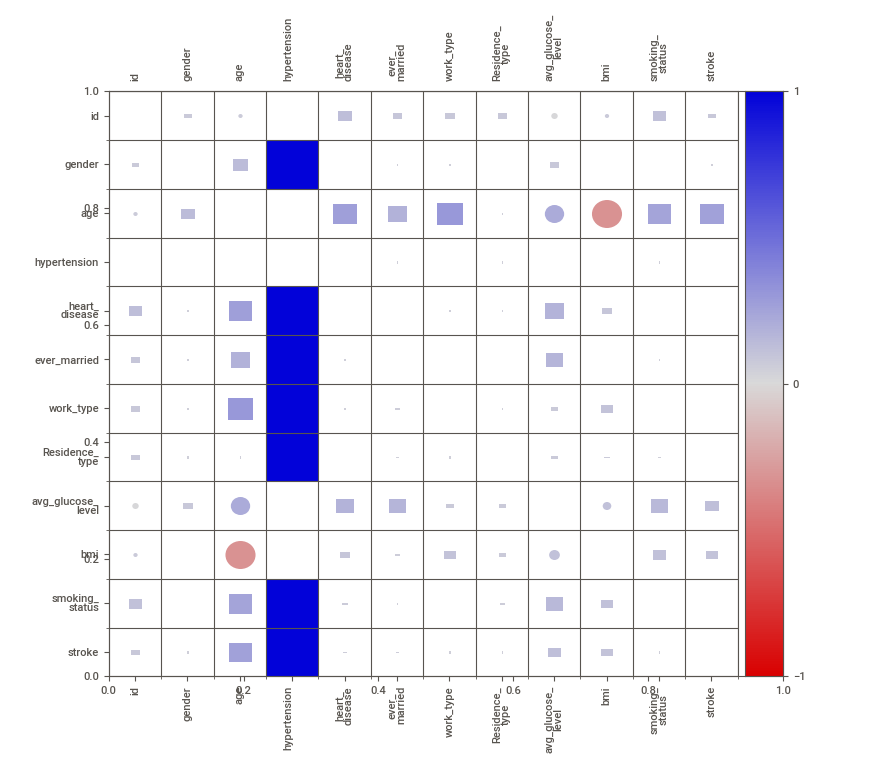
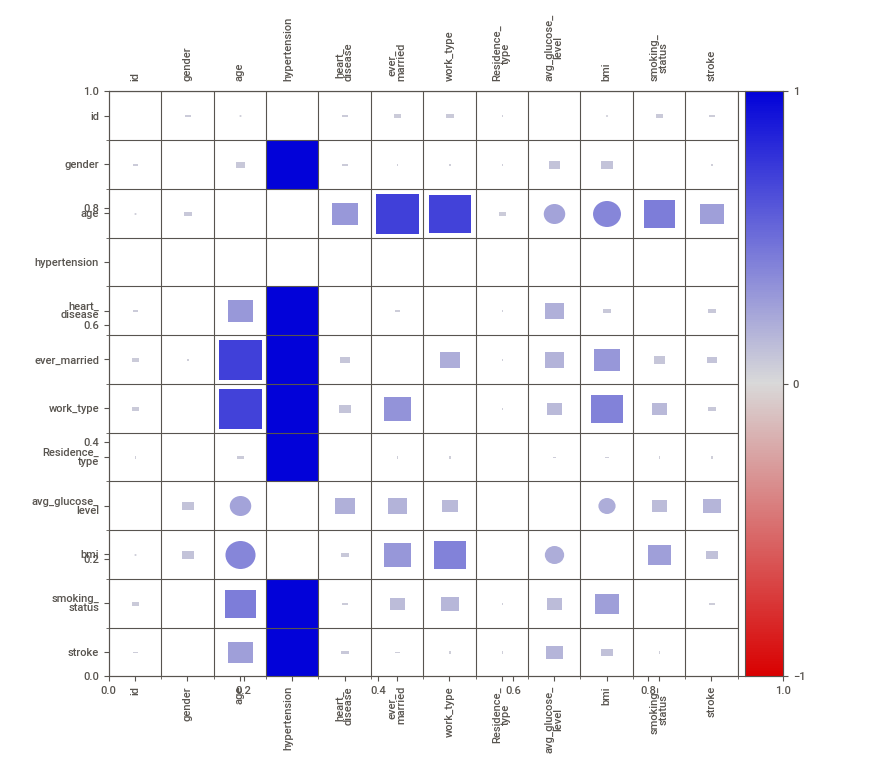

In [9]:
report_sv_hp = sv.compare_intra(data, data["hypertension"] == 1, ["Hipertensión", "No hipertensión"])
report_sv_hp.show_notebook()

✍️ **Interpretación:**
(Explicar si los cortes generan patrones relevantes respecto al target `stroke`).

El primer corte se realizó en la mediana de la edad (45), siendo los datos en azul aquellos representando a los mayores de 45 años y en naranja a los menores.

Cómo se puede ver en la sección de la característica de `stroke`, sí existe un patron relevante según el corte de edad. Esto ya que se puede ver como, de las 2577 personas mayores de 45 años, 239 (10%) han sufrido un derrame. Lo que contrasta con el hecho de que de las 2533 personas menores de 45, solo 10 (0.4%) han sufrido uno. Relacionando la probabilidad de sufrir un derrame con la edad.

---

El segundo corte se realizó considerando aquellas personas que tienen hipertensión y las que no.

Se puede notar que aquellas personas que sufren de hipertensión son más propensas a sufrir un derrame (13.2%) que aquellas personas que no sufren de esta condición (4%).

Sin embargo, se podría concluir que, entre estos 2 cortes, aquél que divide las personas por la mediana de su edad (45) está más relacionado al riesgo de sufrir un derrame debido a que unicamente un pequeño número de aquellas personas menores de 45 (10) llegaron a sufrir esta condición.


##  Pregunta 3 – Relación entre pares de variables
- Escoger tres pares de variables: categórica×categórica, categórica×numérica y numérica×numérica.  
- Justificar la elección de variables y analizar relaciones encontradas.  


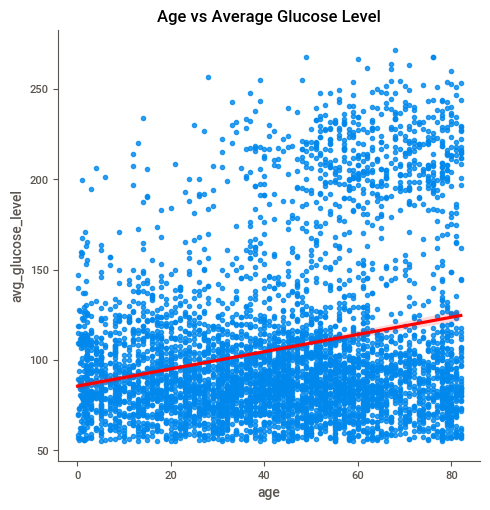

In [10]:
# Código aquí
sns.lmplot(x='age', y='avg_glucose_level', data=data, line_kws={'color': 'red'})
plt.title('Age vs Average Glucose Level')
plt.show()

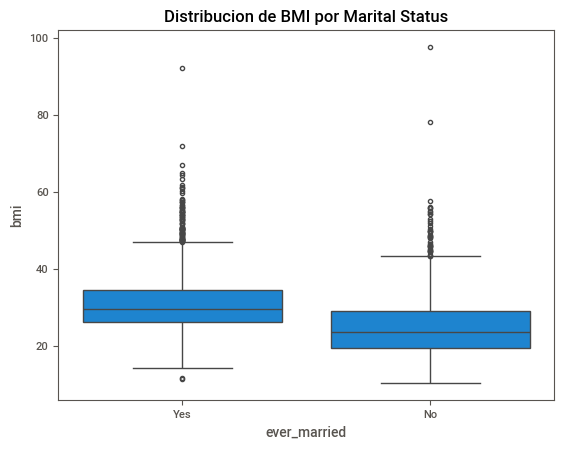

In [11]:
sns.boxplot(x='ever_married', y='bmi', data=data)
plt.title('Distribucion de BMI por Marital Status')
plt.show()

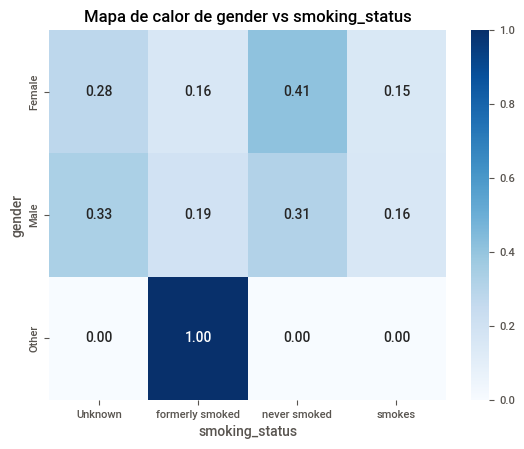

In [12]:
tabla = pd.crosstab(data['gender'], data['smoking_status'], normalize='index')
sns.heatmap(tabla, annot=True, cmap='Blues', fmt=".2f")
plt.title('Mapa de calor de gender vs smoking_status')
plt.show()

✍️ **Interpretación:**
(Analizar relevancia de las relaciones con respecto al target `stroke`).

### Interpretacion de variables Numerica x Numerica (age VS avg_glucose_level)
Se observa que la pendiente ascendente de la regresión indica que a medida que aumenta la edad, también aumenta el nivel promedio de glucosa en sangre. Esta relación la consideramos relevante, pues podria ser el primer indicio que indique que el riesgo de 'stroke' aumenta en pacientes mayores con niveles más altos de glucosa.

### Interpretacion de variabes Categorica x Numerica (ever_married VS bmi)
El grupo de personas que han estado casadas(Yes) tiene una mediana de BMI más alta comparado con el grupo que no lo ha estado ('no'); sugiriendono que en promedio, las personas casadas tienden a tener un índice de masa corporal más elevado. Esta relación podria ser relevante, pues si confirmasemos que un BMI elevado es un factor de riesgo para el 'stroke', esto también podría indicar que el riesgo es mayor en pacientes casados, permitiendo así enfocar nuestra atención en un grupo más específico.

### Interpretacion de variables Categorica x Categorica (gender VS smoking_status)
Las mujeres presentan una mayor proporción de personas que nunca han fumado, mientras que los hombres tienen porcentajes más altos. Esta diferencias podrían ser relevantes, ya que de llegar a confirmar si los fumadores o exfumadores tienden a presentar un 'stroke' positivo, estas podrían ayudar a identificar otro grupo de mayor riesgo.


##  Pregunta 4 – Preprocesamiento con Pipelines
- Implementar un **pipeline de sklearn/imblearn** que incluya:  
  - Conversión de variables categóricas.  
  - Escalado de numéricas.  
  - Estrategia de **balanceo de clases** (ej. SMOTE, undersampling o class_weight).  
- Comparar desempeño con un clasificador auxiliar antes y después del pipeline.  


In [13]:
# Código aquí

✍️ **Interpretación:**
(Justificar elecciones de preprocesamiento y analizar impacto en desempeño).


## Pregunta 5 – Feature Engineering
- Crear al menos **dos nuevas variables derivadas**.  
- Explicar la lógica detrás de estas transformaciones.  
- Evaluar con un clasificador auxiliar si mejoran el desempeño predictivo.  


In [14]:
# Código aquí

✍️ **Interpretación:**
(Explicar lógica de las variables creadas y comparar desempeño con/sin ellas).


# Rúbrica de Evaluación – Práctica Calificada

| Pregunta | Criterio | Descripción | Puntaje Máximo |
|----------|-----------|-------------|----------------|
| **1. EDA con librerías automáticas** | Codificación | Implementa correctamente el EDA con SweetViz y otra librería. | **1.5** |
| | Interpretación | Explica hallazgos, compara herramientas, identifica ventajas/desventajas. | **2.5** |
| **2. Análisis por cortes** | Codificación | Realiza correctamente los cortes en dos variables y presenta resultados claros. | **1.5** |
| | Interpretación | Justifica la elección de variables, interpreta patrones y su relación con el target. | **2.5** |
| **3. Relación entre pares de variables** | Codificación | Escoge tres pares (cat×cat, cat×num, num×num) y aplica correctamente métodos de análisis. | **1.5** |
| | Interpretación | Justifica selección, analiza relaciones y discute relevancia en `stroke`. | **2.5** |
| **4. Preprocesamiento con Pipelines** | Codificación | Implementa pipeline con categóricas, escalado y balanceo. Evalúa antes y después. | **1.5** |
| | Interpretación | Justifica decisiones, analiza impacto en desempeño, discute limitaciones. | **2.5** |
| **5. Feature Engineering** | Codificación | Crea al menos dos nuevas variables, integra y evalúa con clasificador auxiliar. | **1.5** |
| | Interpretación | Explica lógica de transformaciones, analiza relevancia y compara desempeño. | **2.5** |

**Total por pregunta:** 4 puntos  
**Total práctica:** 20 puntos  
